In [3]:
import json
from pathlib import Path
import jax
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import serialization as sz
import pandas as pd
from numpyro.infer import NUTS, MCMC, init_to_median
import jax.random as jr
import numpyro
import numpyro.distributions as dist

from model import (
    MiniGPJax,
    # kernel / mean / likelihood classes
    RBF, Matern32, GaussianLikelihood, ZeroMean, GPParams, Standardizer,
    # state (de)serializers defined in your file
    _kernel_to_state, _kernel_from_state,
    _lik_to_state, _lik_from_state,
    _zeromean_to_state, _zeromean_from_state,
    _gpparams_to_state, _gpparams_from_state,
    _std_to_state, _std_from_state,
)
from model import MiniGPJax, _register_all_serializers_once
_register_all_serializers_once()

In [8]:
TRAIN_CSV = "Completed_Train_set_3.csv" #Completed_train_set_10_30_25.csv#"Train_Set_2.csv"
TEST_CSV  = "Completed_Test_set_3.csv"#"Test_Set_2.csv"
CKPT_DIR  = "ckpts/gp_run_005"
dim = 5
gp = MiniGPJax(
    dim=dim,
    kernel="rbf",            # or "matern32" I dont have the others
    fixed_noise=None,        # consider None to learn noise for better generalization
    standardize_x=True,
    standardize_y=True,
    log_y=True,              # ensures: log -> standardize (train stats) -> fit
    jitter=1e-6,
)
gp.load(TRAIN_CSV, TEST_CSV)
gp.fit(lbfgs_max_iter=30, lbfgs_tol=1e-7, num_restarts=2, seed=200)

#

[ok] Loaded train: X=(1024, 5), y=(1024,) (log→std)
[ok] Loaded test:  X=(256, 5), y=(256,) (log→std)
[restart 0] nLML = -1756.754517
[restart 1] nLML = -1756.754517
[ok] Best nLML = -1756.754517
[fit] amp=2.356 | noise_var=2.588e-05 | ell=[5.136 1.915 9.435 0.417 3.39 ]
[fit] train RMSE(z)=0.0040 | R²(z)=1.0000  (z = standardized)


In [12]:
gp.evaluate_and_plot(outdir="12_14_2025")  # defaults to "log" when log_y=True


[eval:log] RMSE(log)=0.036881 | MAE(log)=0.013797 | R²(log)=0.998990


{'rmse_log': 0.03688124939799309,
 'mae_log': 0.013796549290418625,
 'r2_log': 0.9989898231403537}

In [13]:
_register_all_serializers_once()
gp.save_checkpoint(CKPT_DIR)

[save] Wrote checkpoint to: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_005


In [14]:
CKPT_DIR = "ckpts/gp_run_005"
TRAIN_CSV = "Completed_Train_set_3.csv"
_register_all_serializers_once()
gp_loaded = MiniGPJax.ready_from_checkpoint(CKPT_DIR, train_csv=TRAIN_CSV, rebuild=True)

[load] Loaded config+params from: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_005
[posterior] Rebuilt training posterior.


# Sanity check

In [17]:
x_single = np.array([[0.68,4823,0.39,9.,3.45E-07]], dtype=np.float32)  # shape (1, 5)

mu, std = gp_loaded.predict(x_single)
print(mu/1e7, std/1e7)

[0.2216119] [0.00215605]


In [416]:

def _gp_predict_mean_jax(Xnew: jnp.ndarray) -> jnp.ndarray:
    """
    JAX-only version of gp.predict that returns the predictive MEAN
    in original y units (with log_y lognormal correction if needed).

    Xnew: (N, dim) jnp array
    Returns: (N,) jnp array
    """
    # Standardize X with the fitted Standardizer
    Xn = gp_loaded.std.transform_X(Xnew)

    # Posterior in z-space (standardized log(y) if log_y=True)
    mean_z, std_z = gp_loaded.posterior.predict(Xn, include_noise=True)  # both jnp

    # Undo standardization (still log-space if log_y=True)
    mean_z, std_z = gp_loaded.std.inverse_y(mean_z, std_z)

    if gp_loaded.log_y:
        # log-normal moment correction (same as gp.predict)
        mu    = mean_z
        sigma = std_z
        y_mean = jnp.exp(mu + 0.5 * (sigma ** 2))  # E[Y]
        return y_mean  # (N,)
    else:
        return mean_z  # (N,)


def gp_single_x(x1, x2, x3, x4, x5):
    x = jnp.stack([x1, x2, x3, x4, x5])
    #return(x.shape)
    return _gp_predict_mean_jax(jnp.array([x]))[0]

gp_flow_maps = jax.vmap(gp_single_x, (None, None, None, None, 0))

In [417]:
_gp_predict_mean_jax(x_single)



Array([2119863.2], dtype=float32)

In [428]:
flows = jnp.array([2.4e-7, 3.45e-7, 6.5e-7])
x1 =0.64
x2 = 4300
x3 = 0.01
x4 = 9.6


## gp_flows_maps is the vectorized version

In [429]:

prins = gp_flow_maps(x1, x2, x3, x4, flows)/6894.76 

print(prins)

[176.55458 221.16623 335.16602]


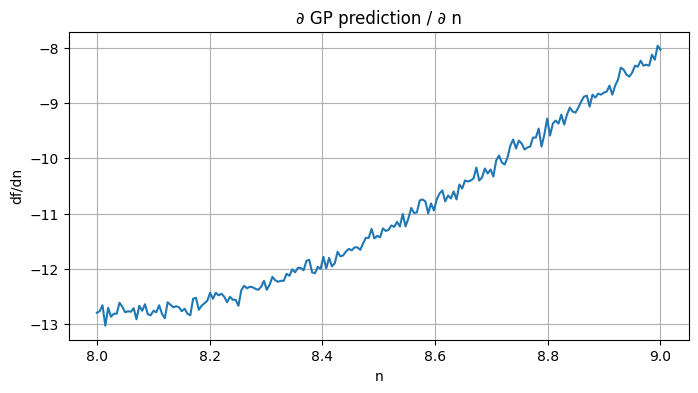

In [443]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# ---- choose a flow ----
flow_fixed = flows    # choose the first flow, or any scalar flow value

# ---- fix other parameters ----
x2_fixed = 5000.0          # because earlier you used x2/10
x3_fixed = 0.01
x1_fixed = 0.64

# ---- define f(n) ----
def f_n(n):
    return gp_flow_maps(x1_fixed, x2_fixed, x3_fixed, n, flow_fixed)[0] / 6894.76

# ---- gradient of f w.r.t. n ----
g = jax.grad(f_n)

# ---- sweep over n in the range you are sampling ----
ns = jnp.linspace(8., 9., 200)

vals = []
grads = []
for n in ns:
    vals.append(f_n(n))
    grads.append(g(n))

# ---- convert to arrays ----
vals = jnp.array(vals)
grads = jnp.array(grads)

# ---- plot gradients ----
plt.figure(figsize=(8,4))
plt.plot(ns, grads)
plt.xlabel("n")
plt.ylabel("df/dn")
plt.title("∂ GP prediction / ∂ n")
plt.grid(True)
plt.show()

# process data


In [163]:
df = pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Pressure")               
df.head()

subset = df.iloc[1:, 2:6]
# Make the first row the header

new_header = subset.iloc[0]   # get the first row
subset = subset[1:]           # take the data after the header row
subset.columns = new_header   # set header
subset = subset.reset_index(drop=True)  # clean index
print(subset.head())

pressure = subset['Pump Pressure(PSI)'].values[1:]
pressure_times = subset['Time(s)'].values[1:]

1   Time(s) Extruder Pressure (PSI) Pump Pressure(PSI) Temperature(C)
0         0               687.94829         332.927429     279.594642
1  0.060966              721.002479         305.609107     279.594642
2  0.108939              747.514903         285.115698     279.594642
3  0.154912               767.74587         270.662268     279.594642
4  0.200885              781.886558          261.56303     279.594642


(array([1.000e+00, 1.000e+00, 1.119e+03, 7.230e+02, 1.200e+01, 7.800e+01,
        1.363e+03, 4.850e+02, 1.000e+00, 1.000e+00]),
 array([-2.11480363, -1.53596184, -0.95712005, -0.37827827,  0.20056352,
         0.77940531,  1.35824709,  1.93708888,  2.51593067,  3.09477245,
         3.67361424]),
 <BarContainer object of 10 artists>)

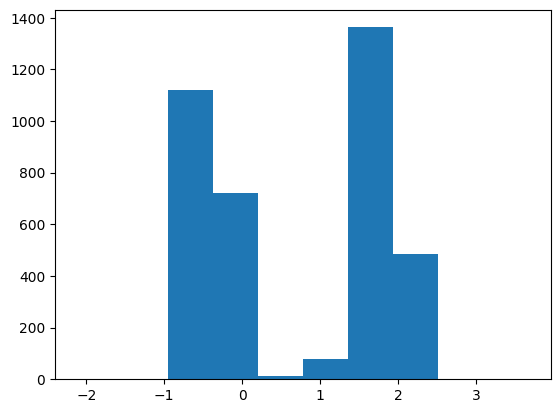

In [164]:
df= pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Position")
df.head()
columns_to_drop = [0, 1,7, 9, 10, 11, 12]

df.drop(df.columns[columns_to_drop], axis=1, inplace=True)


subset = df.iloc[1:, :]
new_header = subset.iloc[0]
subset.columns = new_header
subset = subset.reset_index(drop=True)  # clean index
subset.head()

# xreate all the ararys 

time = subset['Time(seconds)'].values[1:]
x_locs = subset['x(mm)'].values[1:]
y_locs = subset['y(mm)'].values[1:]
z_locs = subset['z(mm)'].values[1:]
speeds = subset['Speed (mm/s)'].values[1:]
flow_rates = subset['Flowrate[m^3/s]'].values[1:]

extract_flow = 2.91582835522733e-07
mask = (flow_rates > 0.96 * extract_flow) & (flow_rates < 1.04 * extract_flow)
plt.hist((flow_rates[np.argwhere(mask)] - extract_flow)/extract_flow * 100)

In [165]:
# cleaned version of my code above from CHATGPT

def middle50_slice(n: int):
    i0 = int(0.25 * n)
    i1 = max(int(0.75 * n), i0 + 1)
    return i0, i1
    
def steady_mean_of_segment(times: np.ndarray, pressures: np.ndarray):
    """mean and standard error from the middle 50% of the time segment."""
    times = np.asarray(times)
    pressures = np.asarray(pressures, dtype=float)

    i0, i1 = middle50_slice(len(pressures))
    x = pressures[i0:i1]

    m = np.mean(x)
    s = np.std(x, ddof=1) if x.size > 1 else np.nan
    se = s / np.sqrt(x.size) if x.size > 1 else np.nan
    return m, se
    
def extract_layer_data(layer: int,
                       layer_height: float,
                       z_locs: np.ndarray,
                       time: np.ndarray,
                       speeds: np.ndarray,
                       flow_rates: np.ndarray,
                       pressure_times: np.ndarray,
                       pressure: np.ndarray,
                       extract_flow: float,
                       flow_sensor_error_percentage: float = 1.0):
    """
    Extracts steady-state flow and corresponding pressure data for a given layer.

    Parameters
    ----------
    layer : int
        Layer number (1-indexed).
    layer_height : float
        Height of one layer in mm.
    z_locs : np.ndarray
        Array of z-locations (same length as `time` and `flow_rates`).
    time : np.ndarray
        Array of timestamps for flow measurements.
    speeds : np.ndarray
        Array of speeds corresponding to each time.
    flow_rates : np.ndarray
        Array of flow rate measurements.
    pressure_times : np.ndarray
        Array of timestamps for pressure measurements.
    pressure : np.ndarray
        Array of pressure values.
    extract_flow : float
        Expected flow rate to extract steady-state region.
    flow_sensor_error_percentage : float, optional
        Allowed sensor error in %, default 5%.

    Returns
    -------
    dict
        Dictionary containing:
        - 'times_speeds': np.ndarray of times during steady-state
        - 'flow_rates_ss': np.ndarray of steady-state flow rates
        - 'pressure_times_ss': np.ndarray of matching pressure times
        - 'pressures_ss': np.ndarray of matching pressure values
        - 'mask_flow_rates': np.ndarray of indices of steady-state flow points
    """

    # Compute allowed flow rate range
    extract_flow_min = extract_flow * (1 - 0.01 * flow_sensor_error_percentage)
    extract_flow_max = extract_flow * (1 + 0.01 * flow_sensor_error_percentage)

    # Extract layer
    mask_layer = np.argwhere(
        (z_locs >= layer_height * (layer - 1)) & (z_locs < layer_height * layer)
    ).flatten()
    times_layer = time[mask_layer]
    speeds_layer = speeds[mask_layer]
    flow_rates_layer = flow_rates[mask_layer]

    # Steady-state flow mask
    mask_flow = np.argwhere(
        (flow_rates_layer >= extract_flow_min) & (flow_rates_layer <= extract_flow_max)
    ).flatten()
    times_speeds = times_layer[mask_flow]
    flow_rates_ss = flow_rates_layer[mask_flow]

    # Matching pressure segment
    if len(times_speeds) > 0:
        time_range = np.array([np.min(times_speeds), np.max(times_speeds)])
        mask_pressure = np.argwhere(
            (pressure_times >= time_range[0]) & (pressure_times <= time_range[1])
        ).flatten()
        pressure_times_ss = pressure_times[mask_pressure]
        pressures_ss = pressure[mask_pressure]
    else:
        pressure_times_ss = np.array([])
        pressures_ss = np.array([])

    return {
        "times_speeds": times_speeds,
        "flow_rates_ss": flow_rates_ss,
        "pressure_times_ss": pressure_times_ss,
        "pressures_ss": pressures_ss,
        "mask_flow_rates": mask_flow,
    }

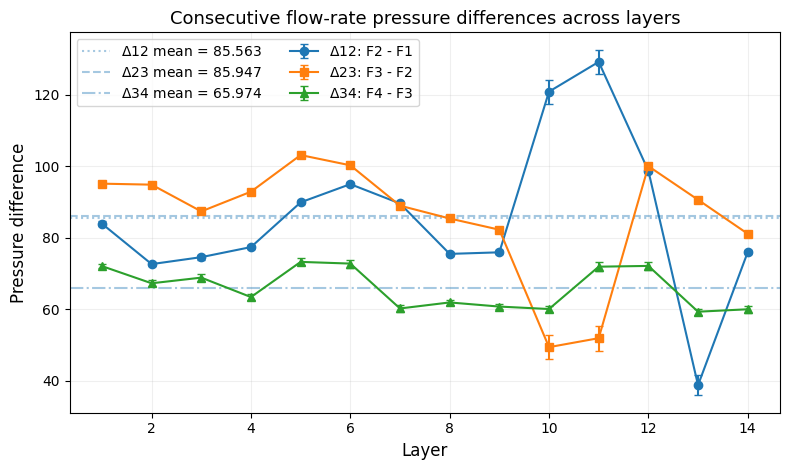

\Delta 12: mean=85.5635, std_across_layers=21.9971, n=14, median_SE=0.6142
\Delta 23: mean=85.9465, std_across_layers=16.3597, n=14, median_SE=0.6397
\Delta 34: mean=65.9743, std_across_layers=5.6731, n=14, median_SE=0.9143


In [166]:
flows = np.array([
    2.91582835522733e-07,
    4.84503201019647e-07,
    6.87113630536953e-07,
    8.89724060054260e-07,
], dtype=np.float32)

# ---------- collect per-layer steady means ----------
n_layers = 14
means = np.full((n_layers, 4), np.nan)
sems  = np.full((n_layers, 4), np.nan)

# NEW: store per-layer average measured flow for each of the 4 flow setpoints
flow_means = np.full((n_layers, 4), np.nan)
flow_sems  = np.full((n_layers, 4), np.nan)

def pick_first_key(d: dict, candidates):
    for k in candidates:
        if k in d and d[k] is not None:
            return d[k]
    return None

for layer in range(1, n_layers + 1):
    for k, flow in enumerate(flows):
        res = extract_layer_data(
            layer=layer,
            layer_height=1.5,
            z_locs=z_locs,
            time=time,
            speeds=speeds,
            flow_rates=flow_rates,
            pressure_times=pressure_times,
            pressure=pressure,
            extract_flow=flow,
            flow_sensor_error_percentage=4.0,
        )

        # ----- pressure steady-state stats (existing) -----
        pt = res["pressure_times_ss"]
        pv = res["pressures_ss"]
        m, se = steady_mean_of_segment(pt, pv)
        means[layer-1, k] = m
        sems[layer-1, k]  = se

        # ----- flow steady-state stats (NEW) -----
        # Try to read steady-state flow directly if provided by extract_layer_data
        ft = pick_first_key(res, ["flow_times_ss", "flowrate_times_ss", "flow_rate_times_ss"]) or pt
        fv = pick_first_key(res, ["flow_rates_ss", "flowrate_ss", "flows_ss", "flow_ss"])

        if fv is None:
            # Fallback: estimate from the raw flow_rates around the commanded flow ± sensor error,
            # within the same time indices used for pressure steady-state, if available.
            # Try to get the boolean mask / indices for the steady window:
            mask_ss = pick_first_key(res, ["mask_ss", "steady_mask", "ss_mask"])
            if mask_ss is not None and mask_ss.shape == flow_rates.shape:
                cand = flow_rates[mask_ss]
            else:
                # last-resort: just band around the setpoint across all samples
                band = 0.04 * flow
                mask = (flow_rates > (flow - band)) & (flow_rates < (flow + band))
                cand = flow_rates[mask]

            if cand.size > 1:
                fm, fse = float(np.mean(cand)), float(np.std(cand, ddof=1) / np.sqrt(cand.size))
            elif cand.size == 1:
                fm, fse = float(cand[0]), np.nan
            else:
                fm, fse = np.nan, np.nan
        else:
            # We have steady-state flow vector fv (and possibly its times ft)
            fm, fse = steady_mean_of_segment(ft, fv)

        flow_means[layer-1, k] = fm
        flow_sems[layer-1, k]  = fse

# ---------- consecutive differences & error propagation (unchanged) ----------
d12 = means[:, 1] - means[:, 0]
d23 = means[:, 2] - means[:, 1]
d34 = means[:, 3] - means[:, 2]

sd12 = np.sqrt(sems[:, 1]**2 + sems[:, 0]**2)
sd23 = np.sqrt(sems[:, 2]**2 + sems[:, 1]**2)
sd34 = np.sqrt(sems[:, 3]**2 + sems[:, 2]**2)

layers = np.arange(1, n_layers + 1)

# ---------- plot (unchanged) ----------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(layers, d12, yerr=sd12, fmt='o-', capsize=3, label=r'$\Delta 12$: F2 - F1')
ax.errorbar(layers, d23, yerr=sd23, fmt='s-', capsize=3, label=r'$\Delta 23$: F3 - F2')
ax.errorbar(layers, d34, yerr=sd34, fmt='^-', capsize=3, label=r'$\Delta 34$: F4 - F3')

for d, name, ls in [(d12, r'$\Delta 12$ mean', ':'), (d23, r'$\Delta 23$ mean', '--'), (d34, r'$\Delta 34$ mean', '-.')]:
    mu = np.nanmean(d)
    ax.axhline(mu, linestyle=ls, alpha=0.4, label=fr'{name} = {mu:.3f}')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Pressure difference', fontsize=12)
ax.set_title('Consecutive flow-rate pressure differences across layers', fontsize=13)
ax.legend(ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------- quick numeric summary (unchanged) ----------
def summarize(name, d, sd):
    valid = np.isfinite(d)
    mu = np.nanmean(d)
    sdv = np.nanstd(d, ddof=1)
    print(f"{name}: mean={mu:.4f}, std_across_layers={sdv:.4f}, "
          f"n={valid.sum()}, median_SE={np.nanmedian(sd):.4f}")

summarize(r"\Delta 12", d12, sd12)
summarize(r"\Delta 23", d23, sd23)
summarize(r"\Delta 34", d34, sd34)

# ---------- NEW: per-layer average flow arrays ----------
f1, f2, f3, f4 = (flow_means[:, 0], flow_means[:, 1], flow_means[:, 2], flow_means[:, 3])

In [170]:


x1 =0.64
x2 = 4823
x3 = 0.0039
x4 = 9.9

pres_f1 = gp_flow_maps(x1, x2, x3, x4, f1)
pres_f2 = gp_flow_maps(x1, x2, x3, x4, f2)
pres_f3 = gp_flow_maps(x1, x2, x3, x4, f3)
pres_f4 = gp_flow_maps(x1, x2, x3, x4, f4)

print(pres_f1/ 6894.76)
print(pres_f2/ 6894.76)
print(pres_f3/ 6894.76)
print(pres_f4/ 6894.76)

[222.39104 221.8693  221.98189 221.80856 222.58603 222.20746 222.08435
 222.10194 222.23926 221.96536 222.09898 221.93553 222.21104 221.41652]
[309.8582  311.06265 308.99387 310.2216  309.47427 311.3021  309.63162
 310.42786 310.17392 309.92618 310.27777 310.0054  311.34995 309.09967]
[381.22116 381.47864 380.63696 380.535   380.5535  381.48044 381.9173
 381.31857 380.6439  381.56668 382.2135  381.64346 382.11948 381.6824 ]
[447.96432 447.82767 448.47647 448.38577 447.88834 448.5329  448.85858
 447.58514 448.71133 448.37338 449.9171  447.14148 449.22726 448.28235]


In [171]:
print(pres_f2/6894.76 - pres_f1/ 6894.76)
print(pres_f3/ 6894.76 - pres_f2/ 6894.76)
print(pres_f4/ 6894.76 - pres_f3/ 6894.76)



[87.46715  89.19336  87.01198  88.413025 86.888245 89.094635 87.54727
 88.32591  87.93466  87.960815 88.17879  88.06987  89.1389   87.68315 ]
[71.362976 70.415985 71.6431   70.313416 71.07922  70.178345 72.285675
 70.89072  70.46997  71.6405   71.93573  71.63806  70.76953  72.58273 ]
[66.743164 66.34903  67.83951  67.85077  67.33484  67.05246  66.941284
 66.26657  68.067444 66.8067   67.70361  65.49802  67.10779  66.599945]


## some variables need to be re arranged

In [172]:
F = jnp.concatenate([f1[:, None],f2[:, None],f3[:, None],f4[:, None]], axis =1)

D = jnp.concatenate([d12[:, None], d23[:, None], d34[:, None]], axis = 1)

D.shape

(14, 3)

## Sanity checks please

In [343]:
# flows = jnp.array([2.4e-7, 3.45e-7, 6.5e-7])
x1 =0.68
x2 = 2.8e3
x3 = 0.1
x4 = 7.9


prins1 = gp_flow_maps(x1, x2, x3, x4, F[:, 0])
prins2 = gp_flow_maps(x1, x2, x3, x4, F[:, 1])
print(prins2/6894.76- prins1/6894.76)

[72.74347  73.538956 72.48082  73.670975 72.01982  74.25795  72.34207
 72.734665 72.369995 73.462906 72.64308  73.97266  72.52608  73.19595 ]


### Will probably need limits of x1 to x4 to ensure we dont go beyond GP training.

## could always sample in beta and then transform

In [190]:
import jax
import jax.numpy as jnp

def gp_flow_maps(x1, x2, x3, x4, flows):
    """
    x1, x2, x3, x4: scalars (hyperparameters)
    flows: (N,) array of flow rates
    returns: (N,) predicted pressures in SAME units as _gp_predict_mean_jax
    """
    flows = jnp.asarray(flows)
    N = flows.shape[0]

    x1_col = jnp.full((N,), x1)
    x2_col = jnp.full((N,), x2)
    x3_col = jnp.full((N,), x3)
    x4_col = jnp.full((N,), x4)

    # Xnew: (N, 5) = [x1, x2, x3, x4, flow]
    Xnew = jnp.stack([x1_col, x2_col, x3_col, x4_col, flows], axis=-1)

    return _gp_predict_mean_jax(Xnew)  # already returns (N,)

# (optional but often helpful)
gp_flow_maps = jax.jit(gp_flow_maps)

In [257]:
import jax
import jax.numpy as jnp

def pressure_diffs(theta, F):
    """
    theta: shape (4,) = (x1, x2, x3, x4)
    F: shape (N, 4) flow settings

    Returns r(theta): concatenated diffs, shape (3N,)
    """
    x1, x2, x3, x4 = theta

    f1 = gp_flow_maps(x1, x2, x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1, x2, x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1, x2, x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1, x2, x3, x4, F[:, 3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3

    return jnp.concatenate([d21, d32, d43], axis=0)  # shape (3N,)


def estimate_ridge_directions(F, mu):
    """
    mu: reference point in R^4 (x1,x2,x3,x4) where you already know
        the model fits reasonably well.

    Returns:
      mu, d_u, d_v
    where d_u is the main ridge direction (smallest singular value),
    and d_v is the next "flat-ish" direction.
    """
    # Jacobian J has shape (3N, 4)
    J = jax.jacfwd(pressure_diffs)(mu, F)

    # SVD: J = U S V^T
    # V has shape (4, 4), columns are directions in parameter space
    U, S, Vt = jnp.linalg.svd(J, full_matrices=False)
    V = Vt.T  # shape (4,4)

    # Sort singular values ascending (smallest -> flattest direction)
    # S is already sorted descending by default, so take last columns
    d_u = V[:, -1]   # flattest direction (ridge)
    d_v = V[:, -2]   # second flattest

    # Optional: scale them to reasonable step sizes (e.g., so ±1 std is small-ish move)
    scale_u = 0.5    # tweak these
    scale_v = 0.5
    d_u = scale_u * d_u
    d_v = scale_v * d_v

    return mu, d_u, d_v


In [261]:
mu0 = jnp.array([0.645, 3500., 0.1, 8.0])  # your current midpoint
mu, d_u, d_v = estimate_ridge_directions(F, mu0)
print("mu:", mu)
print("d_u:", d_u)
print("d_v:", d_v)

mu: [6.45e-01 3.50e+03 1.00e-01 8.00e+00]
d_u: [-1.46350685e-05  4.99989510e-01 -3.22245318e-03  2.86318886e-04]
d_v: [ 0.00067588 -0.00323323 -0.4992472   0.02722631]


In [312]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

# ----------------------------------------------------------
# Reference values (center of plausible region)
# ----------------------------------------------------------
MU0_REF      = 3.5e3   # zero-shear viscosity ~3500
LAMBDA0_REF  = 8.0     # onset timescale ~8
ETA_REF      = 0.65    # power-law index ~0.65
DELTA_REF    = 2.0     # log(lambda0/lambda_inf) ~ 2

# STRONG-ish prior scales (informative but not razor-thin)
LOG_MU0_SD     = 0.25   # mu0 ~ factor exp(±0.25) ≈ 1.28
ETA_SD         = 0.25   # n ~ 0.65 ± ~0.06
Z_LAMBDA0_SD   = 0.35   # λ0 latent SD
DELTA_SD       = 0.4    # Delta ~ 2 ± 0.4

# GP training-domain bounds
# x1 = n, x2 = mu0, x3 = mu_inf, x4 = lambda0
x_lb = jnp.array([0.34, 1.0e3, 1e-3, 1e-2])
x_ub = jnp.array([0.90, 1.0e4, 10.0, 12.0])

LAMBDA0_MIN = x_lb[3]
LAMBDA0_MAX = x_ub[3]

# Pressure scaling: psi → dimensionless
Y_SCALE = 20.0   # adjust if your Δ scale is very different


def _squash_to_interval(z, lo, hi):
    """Smoothly map z in R to (lo, hi) via sigmoid."""
    s = jax.nn.sigmoid(z)       # (0,1)
    return lo + (hi - lo) * s   # (lo, hi)


def model_calibrate_diffs(F, D=None):
    """
    Bayesian calibration using Δ21, Δ32, Δ43 with SRB-like parametrization.

    - n in (0,1) via logistic
    - mu0 > 0 via exp(log mu0)
    - lambda0 smoothly constrained to GP domain [LAMBDA0_MIN, LAMBDA0_MAX]
    - Delta ~ around 2, controls shear-thinning width
    - mu_inf = mu0 * exp(-Delta*(1 - n)) (NO extra squashing)
    - outputs scaled by Y_SCALE for better NUTS geometry
    """

    # ------------------------------------------------------
    # 1. Priors (smooth, informative)
    # ------------------------------------------------------

    # log(mu0) ~ Normal(log(MU0_REF), LOG_MU0_SD)
    z_mu0 = numpyro.sample("z_mu0", dist.Normal(0.0, 1.0))
    log_mu0_loc = jnp.log(MU0_REF)
    log_mu0 = log_mu0_loc + LOG_MU0_SD * z_mu0
    mu0 = jnp.exp(log_mu0)    # > 0

    # eta_raw ~ Normal(logit(ETA_REF), ETA_SD) -> eta in (0,1)
    eta_loc_raw = jax.scipy.special.logit(
        jnp.clip(ETA_REF, a_min=1e-4, a_max=1 - 1e-4)
    )
    z_eta = numpyro.sample("z_eta", dist.Normal(0.0, 1.0))
    eta_raw = eta_loc_raw + ETA_SD * z_eta
    eta = jax.nn.sigmoid(eta_raw)
    n = eta   # Carreau-Yasuda exponent

    # λ0 in [LAMBDA0_MIN, LAMBDA0_MAX] via sigmoid
    frac_ref = (LAMBDA0_REF - LAMBDA0_MIN) / (LAMBDA0_MAX - LAMBDA0_MIN)
    frac_ref = jnp.clip(frac_ref, 1e-4, 1.0 - 1e-4)
    lambda0_loc_raw = jax.scipy.special.logit(frac_ref)

    z_lambda0 = numpyro.sample(
        "z_lambda0",
        dist.Normal(lambda0_loc_raw, Z_LAMBDA0_SD)
    )
    lambda0 = _squash_to_interval(z_lambda0, LAMBDA0_MIN, LAMBDA0_MAX)

    # Delta: width of shear-thinning region
    z_delta = numpyro.sample("z_delta", dist.Normal(0.0, 1.0))
    Delta = DELTA_REF + DELTA_SD * jnp.tanh(z_delta)
    numpyro.deterministic("Delta", Delta)

    # ------------------------------------------------------
    # 2. Derived: lambda_inf, mu_inf (NO hard bound), GP inputs
    # ------------------------------------------------------
    lambda_inf = lambda0 * jnp.exp(-Delta)

    # SRB-like relation: small mu_inf for larger Delta * (1-n)
    mu_inf = mu0 * jnp.exp(-Delta * (1.0 - eta))

    x1 = n
    x2 = 0.02
    x3 = mu_inf
    x4 = lambda0

    numpyro.deterministic("n", x1)
    numpyro.deterministic("mu0", x2)
    numpyro.deterministic("mu_inf", x3)
    numpyro.deterministic("lambda0", x4)
    numpyro.deterministic("lambda_inf", lambda_inf)

    # Optional soft regularization to keep mu_inf in a physical ballpark
    # (does NOT hard-clip, just adds a gentle penalty)
    log_mu_inf = jnp.log(jnp.clip(mu_inf, 1e-10, 1e10))
    numpyro.factor(
        "soft_mu_inf_prior",
        dist.Normal(jnp.log(0.1), 1.0).log_prob(log_mu_inf)
    )

    # ------------------------------------------------------
    # 3. GP predictions (psi)
    # ------------------------------------------------------
    f1 = gp_flow_maps(x1, x2, x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1, x2, x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1, x2, x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1, x2, x3, x4, F[:, 3]) / 6894.76

    d21_pred = f2 - f1
    d32_pred = f3 - f2
    d43_pred = f4 - f3

    # ------------------------------------------------------
    # 4. Scale outputs
    # ------------------------------------------------------
    d21_pred_s = d21_pred / Y_SCALE
    d32_pred_s = d32_pred / Y_SCALE
    d43_pred_s = d43_pred / Y_SCALE

    if D is not None:
        d21_obs_s = D[:, 0] / Y_SCALE
        d32_obs_s = D[:, 1] / Y_SCALE
        d43_obs_s = D[:, 2] / Y_SCALE
    else:
        d21_obs_s = d32_obs_s = d43_obs_s = None

    numpyro.deterministic("d21_pred", d21_pred)
    numpyro.deterministic("d32_pred", d32_pred)
    numpyro.deterministic("d43_pred", d43_pred)

    # ------------------------------------------------------
    # 5. Bias terms (scaled space)
    # ------------------------------------------------------
    b21 = numpyro.sample("b21", dist.Normal(0.0, 2.0))
    b32 = numpyro.sample("b32", dist.Normal(0.0, 2.0))
    b43 = numpyro.sample("b43", dist.Normal(0.0, 2.0))

    m21_s = d21_pred_s + b21
    m32_s = d32_pred_s + b32
    m43_s = d43_pred_s + b43

    numpyro.deterministic("m21_s", m21_s)
    numpyro.deterministic("m32_s", m32_s)
    numpyro.deterministic("m43_s", m43_s)

    # ------------------------------------------------------
    # 6. Noise model & likelihood (scaled)
    # ------------------------------------------------------
    s21 = numpyro.sample("s21", dist.HalfNormal(2.0))
    s32 = numpyro.sample("s32", dist.HalfNormal(2.0))
    s43 = numpyro.sample("s43", dist.HalfNormal(2.0))

    numpyro.sample("y21", dist.Normal(m21_s, s21), obs=d21_obs_s)
    numpyro.sample("y32", dist.Normal(m32_s, s32), obs=d32_obs_s)
    numpyro.sample("y43", dist.Normal(m43_s, s43), obs=d43_obs_s)


In [309]:
from numpyro.infer import Predictive
import jax.random as jr

# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

In [310]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'y21_prior' is not defined

In [439]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = 5e4#numpyro.sample("x2", dist.Uniform(2e4, 9e4))
    z3 = numpyro.sample("z3", dist.Normal(-1., 2.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = 0.01#jnp.exp(-4)#jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(9., 1.))   # along ridge
    #v = numpyro.sample("v", dist.Normal(0., 10.))   # across ridge
    x1 = 64.#numpyro.sample("x1", dist.Uniform(50, 70))#100*(0.4 + 0.1 * u)
    x4 = u#9.9 + 5e-3* u + 3e-3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    d21_pred = f2_pres_pred - f1_pres_pred
    d32_pred = f3_pres_pred - f2_pres_pred
    d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]/1000.
        d32_obs  = D[:, 1]/1000.
        d43_obs  = D[:, 2]/1000.
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    b21 = numpyro.sample("b21", dist.Normal(0.0, 0.002)) # dist.Normal(0.0, 4.)
    #b32 = numpyro.sample("b32", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)
    #b43 = numpyro.sample("b43", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)

    m21 = d21_pred/1000. + b21
    #m32 = d32_pred + b32
    #m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    numpyro.deterministic("m21", m21)
    #numpyro.deterministic("m32", m32)
    #numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    s21 = numpyro.sample("s21", dist.HalfNormal(0.02))
    #s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    #s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    #numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    #numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [448]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

Y_SCALE = 2000.0  # you chose 1000; keep explicit

def model_calibrate_diffs(F, D):
    """
    Calibrate only x4 (lambda), everything else fixed.

    F : (N, 4) array of flows
    D : (N, 3) array of Δ pressures in psi; uses D[:,0] = Δ21
    """

    # --- fixed physical parameters ---
    x1 = 60.0        # n = 0.64
    x2 = 4e4         # will be used as x2/10 = 5000 inside GP
    x3 = 0.001        # mu_inf fixed

    # --- reparameterize x4 in (8,10) via unconstrained z_u ---
    z_u = numpyro.sample("z_u", dist.Normal(0.0, 1.0))
    # map R -> (8, 10) with a smooth tanh; you can adjust center/width
    u   = 9.0 + z_u * 1.0
    x4  = u

    numpyro.deterministic("x1", x1)
    numpyro.deterministic("x2", x2)
    numpyro.deterministic("x3", x3)
    numpyro.deterministic("x4", x4)

    # --- GP predictions (psi) ---
    f1 = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76

    d21_pred = f2 - f1  # psi

    # --- scale outputs ---
    d21_pred_s = d21_pred / Y_SCALE
    numpyro.deterministic("d21_pred_s", d21_pred_s)

    if D is not None:
        d21_obs_s = D[:, 0] / Y_SCALE
    else:
        d21_obs_s = None

    # --- bias and noise in scaled units ---
    b21 = numpyro.sample("b21", dist.Normal(0.0, 0.2))  # ~0.2 * 1000 = 200 psi bias
    s21 = numpyro.sample("s21", dist.HalfNormal(1.0))   # ~1 * 1000 = 100 psi noise

    m21 = d21_pred_s + b21
    numpyro.deterministic("m21", m21)

    numpyro.sample("y21", dist.Normal(m21, s21), obs=d21_obs_s)


In [449]:
def run_nuts_calibration(
    F, D,
    seed=111, warmup=700, samples=1500, chains=2,
    target_accept=0.9, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,dense_mass=True,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


warmup:  13%|███████▍                                                | 291/2200 [08:06<53:11,  1.67s/it, 1023 steps of size 3.86e-06. acc. prob=0.86]


KeyboardInterrupt: 

In [ ]:
print(samples.keys())

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

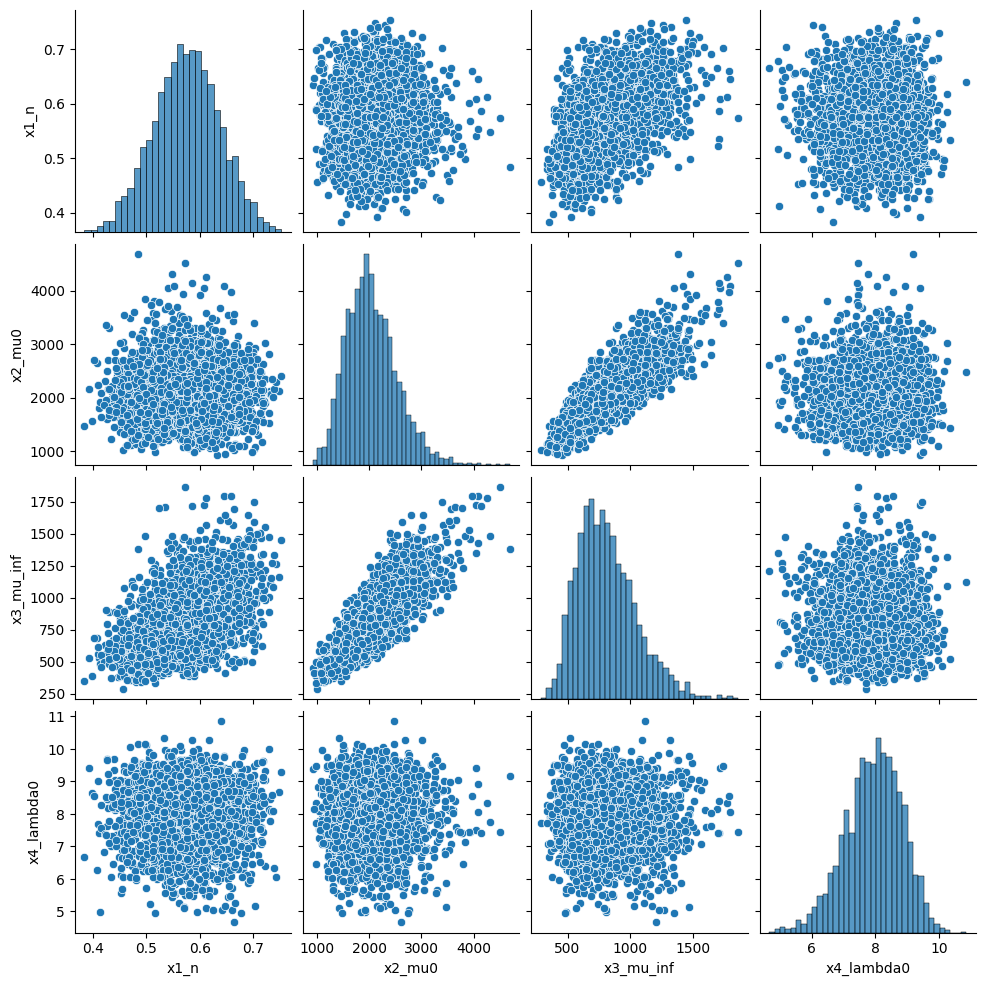

In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get posterior samples
samples = mcmc.get_samples()

# Extract physical parameters (already deterministic nodes!)
x1 = np.asarray(samples["n"])          # x1 = n
x2 = np.asarray(samples["mu0"])        # x2 = mu0
x3 = np.asarray(samples["mu_inf"])     # x3 = mu_inf
x4 = np.asarray(samples["lambda0"])    # x4 = lambda0

# Build DataFrame
df = pd.DataFrame({
    "x1_n":      x1,
    "x2_mu0":    x2,
    "x3_mu_inf": x3,
    "x4_lambda0": x4,
})

sns.pairplot(df)


## prior


In [894]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b21_prior = prior_samples["b21"]
b32_prior = prior_samples["b32"]
b43_prior = prior_samples["b43"]
s21_prior = prior_samples["s21"]
s32_prior = prior_samples["s32"]
s43_prior = prior_samples["s43"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b21_p = np.asarray(b21_prior)
b32_p = np.asarray(b32_prior)
b43_p = np.asarray(b43_prior)
s21_p = np.asarray(s21_prior)
s32_p = np.asarray(s32_prior)
s43_p = np.asarray(s43_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b21":     b21_p,
    "b32":     b32_p,
    "b43":     b43_p,
    "s21":     s21_p,
    "s32":     s32_p,
    "s43":     s43_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b21       b32  \
0  0.457573  4957.405273  0.630753  9.137889 -0.460841  0.384647  0.861604   
1  0.448919  5979.233887  0.029810  9.329538 -3.512919 -0.020355 -0.698096   
2  0.249714  5252.323242  2.335710  8.274053  0.848316 -0.175773  1.279024   
3  0.438283  4336.837891  0.017581  9.670922 -4.040934  1.230969 -0.194498   
4  0.335213  5519.859375  0.153402  9.217848 -1.874691  0.007216  1.132447   

        b43       s21       s32       s43  
0 -0.250010  0.303161  1.000139  0.046411  
1  0.724365  1.384874  1.123531  1.972120  
2  3.010910  1.591959  2.185307  0.740248  
3 -1.133713  2.448206  1.776147  0.732507  
4  1.290156  0.266113  0.239624  0.447475  


In [895]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

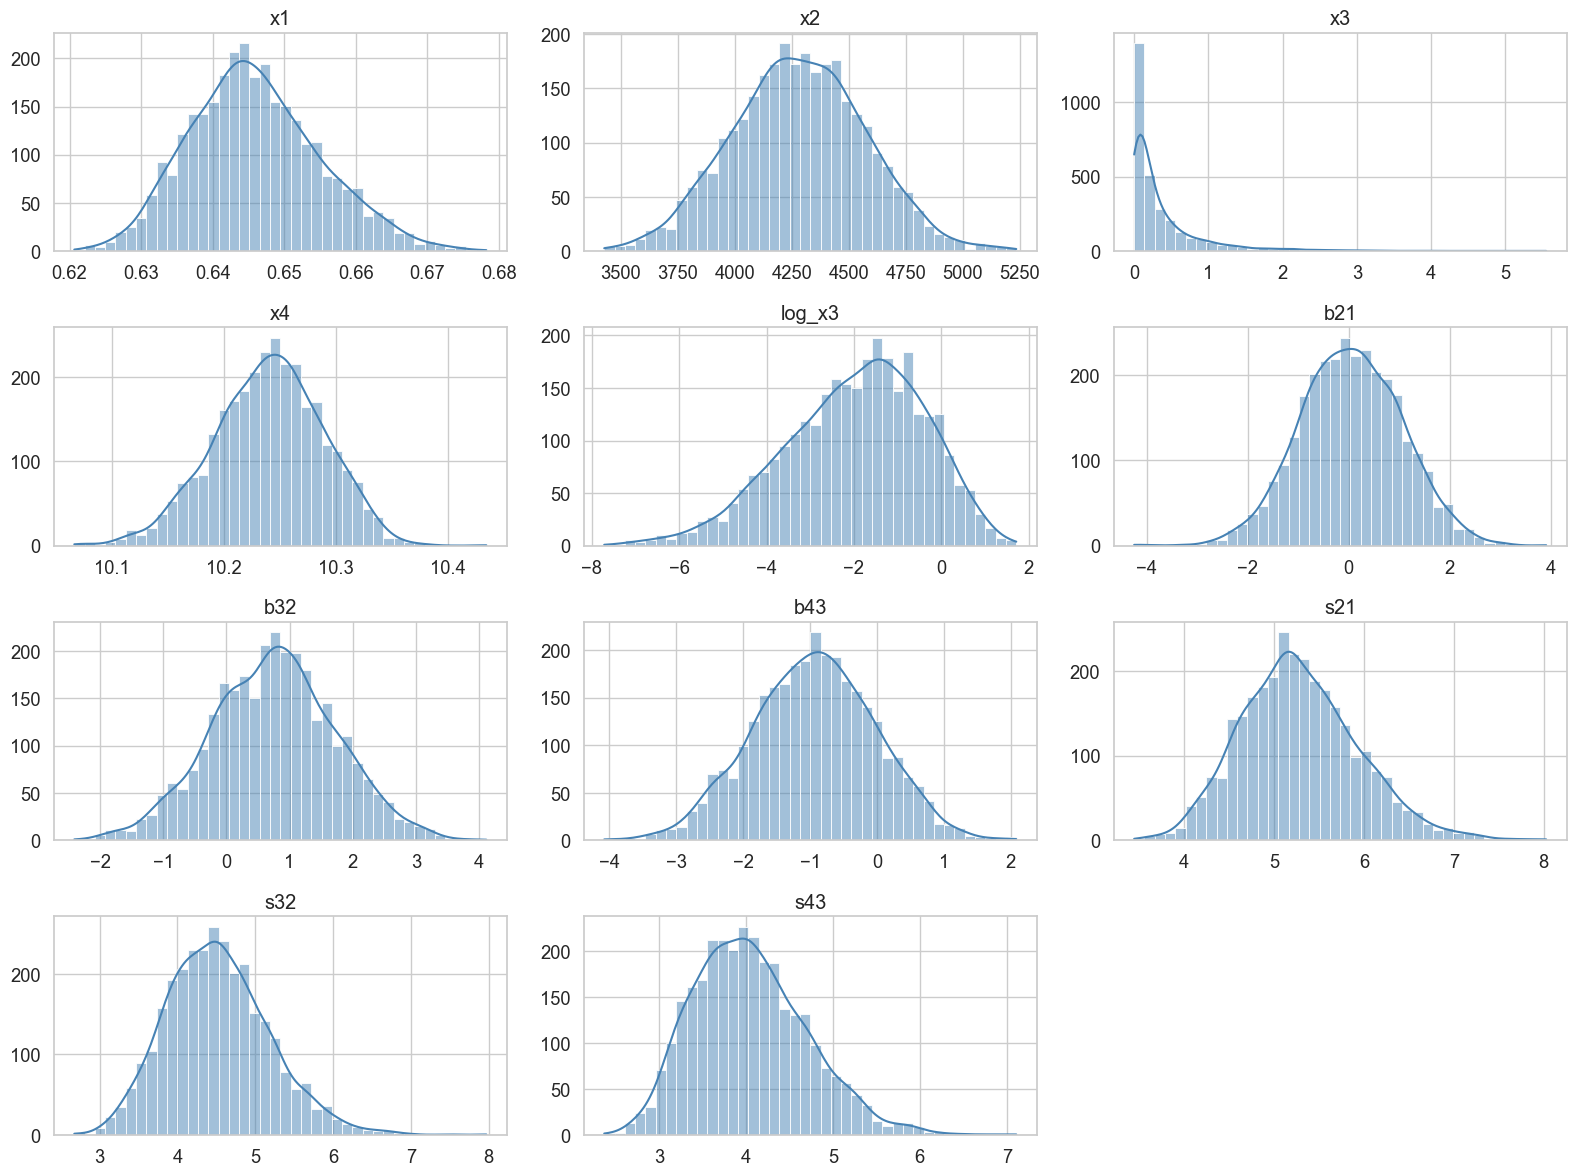

In [896]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

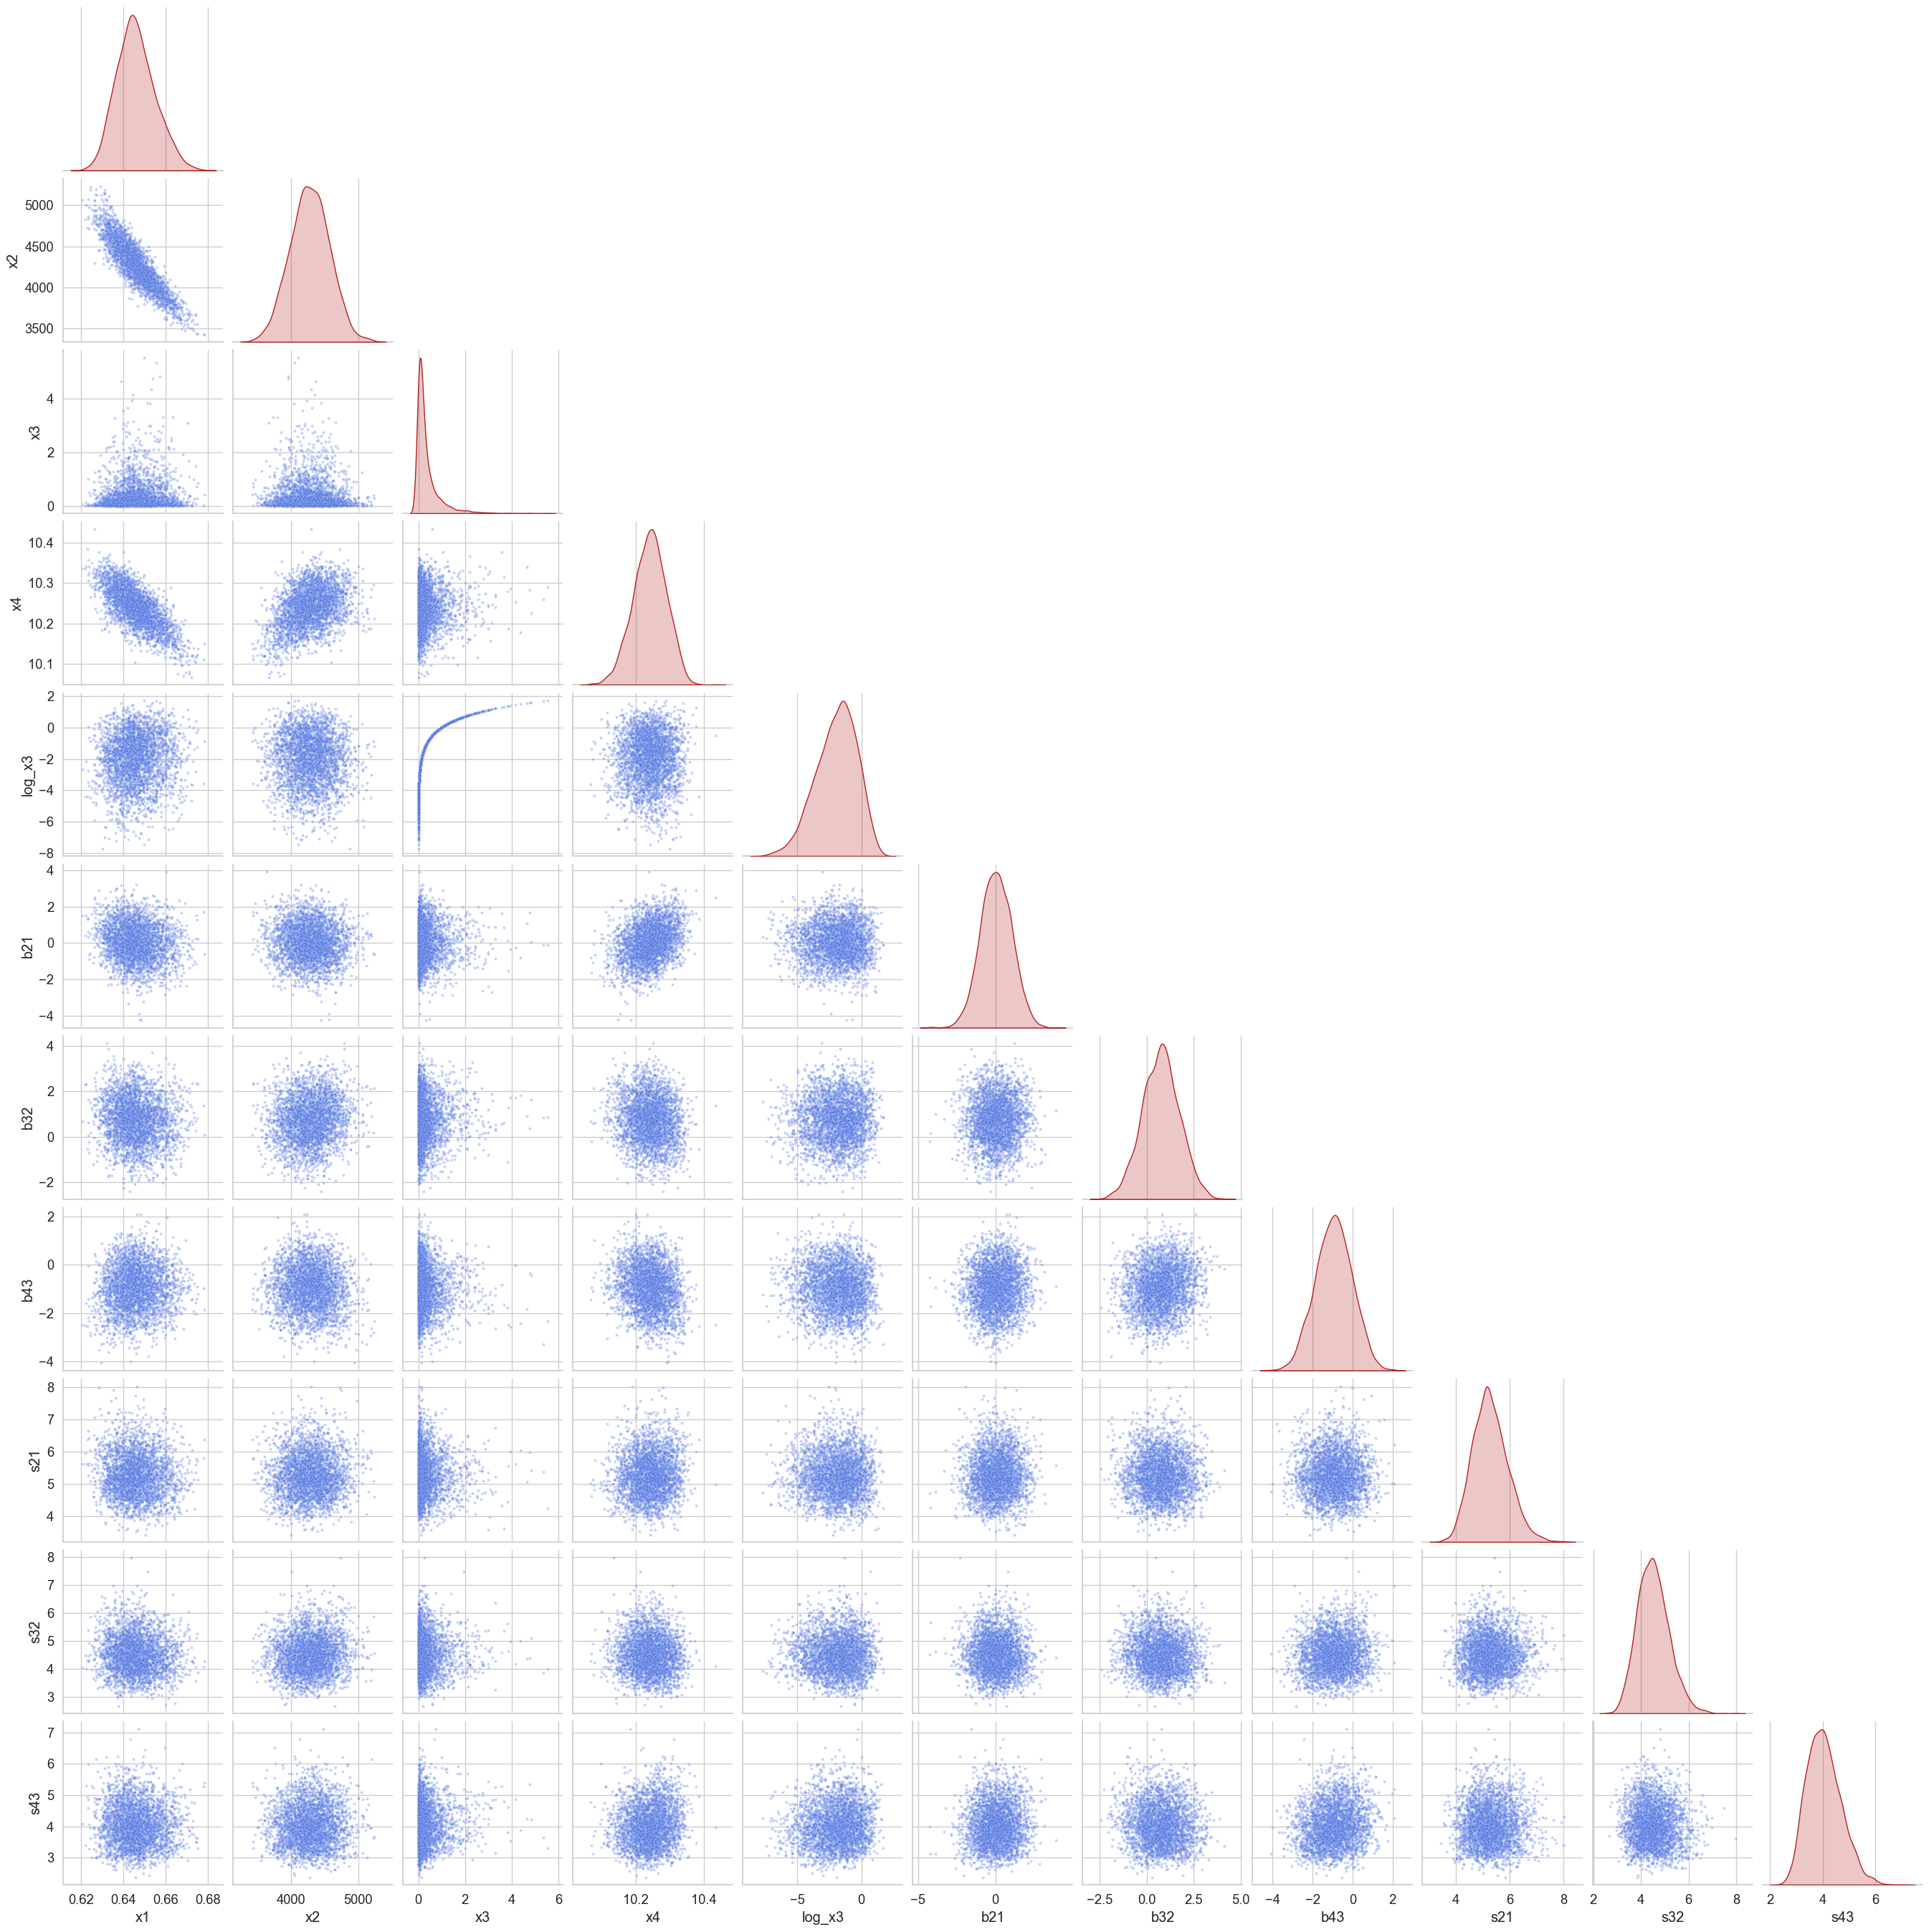

In [897]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="kde",
    diag_kws=dict(fill=True, color="firebrick"),
    plot_kws=dict(s=8, alpha=0.3, color="royalblue")
)
plt.show()


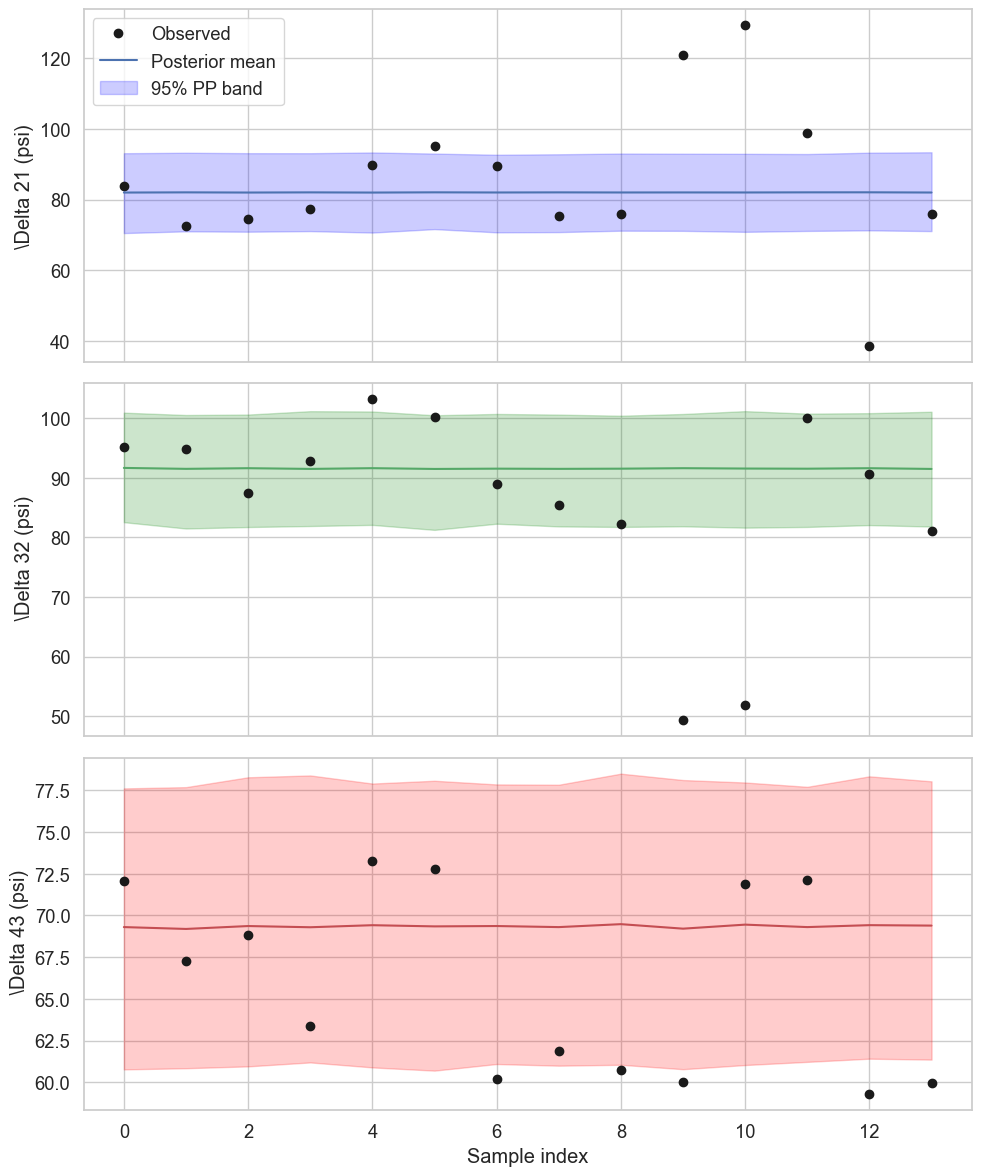

In [898]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values
x2_s  = df["x2"].values * 10.0        # reverse earlier division
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b21_s = df["b21"].values
b32_s = df["b32"].values
b43_s = df["b43"].values

s21_s = df["s21"].values
s32_s = df["s32"].values
s43_s = df["s43"].values

nsamp = len(df)

# ---------------------------------------------
# Compute posterior predictive for each sample
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    f1 = gp_flow_maps(x1, x2, x3, x4, F[:,0]) / 6894.76
    f2 = gp_flow_maps(x1, x2, x3, x4, F[:,1]) / 6894.76
    f3 = gp_flow_maps(x1, x2, x3, x4, F[:,2]) / 6894.76
    f4 = gp_flow_maps(x1, x2, x3, x4, F[:,3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# Storage
m21_all = []
m32_all = []
m43_all = []

y21_all = []
y32_all = []
y43_all = []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i]/10.0, x3_s[i], x4_s[i], F
    )

    # latent means
    m21 = d21 + b21_s[i]
    m32 = d32 + b32_s[i]
    m43 = d43 + b43_s[i]

    # noisy posterior predictive
    y21 = m21 + np.random.normal(0, s21_s[i], size=len(m21))
    y32 = m32 + np.random.normal(0, s32_s[i], size=len(m32))
    y43 = m43 + np.random.normal(0, s43_s[i], size=len(m43))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)

    y21_all.append(y21)
    y32_all.append(y32)
    y43_all.append(y43)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)

y21_all = np.vstack(y21_all)
y32_all = np.vstack(y32_all)
y43_all = np.vstack(y43_all)

# ---------------------------------------------
# Compute posterior predictive summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

m21_mean, m21_lo, m21_hi = summarise(m21_all)
m32_mean, m32_lo, m32_hi = summarise(m32_all)
m43_mean, m43_lo, m43_hi = summarise(m43_all)

y21_mean, y21_lo, y21_hi = summarise(y21_all)
y32_mean, y32_lo, y32_hi = summarise(y32_all)
y43_mean, y43_lo, y43_hi = summarise(y43_all)

# Observed
d21_obs = D[:,0]
d32_obs = D[:,1]
d43_obs = D[:,2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="Posterior mean")
ax.fill_between(x, y21_lo, y21_hi, color="blue", alpha=0.2, label="95% PP band")
ax.set_ylabel("\Delta 21 (psi)")
ax.legend()

# Δ32
ax = axes[1]
ax.plot(x, d32_obs, "ko")
ax.plot(x, m32_mean, "g-")
ax.fill_between(x, y32_lo, y32_hi, color="green", alpha=0.2)
ax.set_ylabel(" \Delta 32 (psi)")

# Δ43
ax = axes[2]
ax.plot(x, d43_obs, "ko")
ax.plot(x, m43_mean, "r-")
ax.fill_between(x, y43_lo, y43_hi, color="red", alpha=0.2)
ax.set_ylabel(" \Delta 43 (psi)")
ax.set_xlabel("Sample index")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


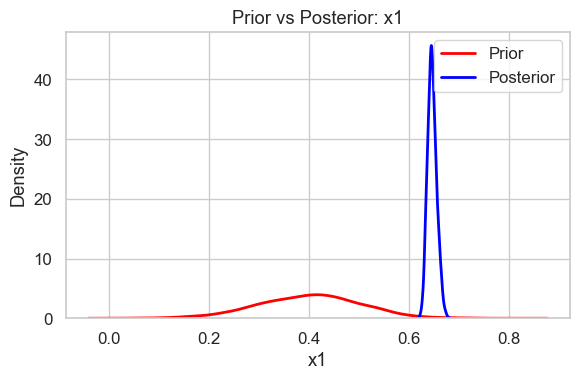

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


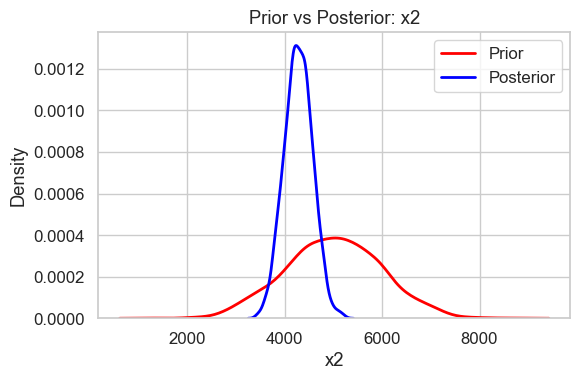

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


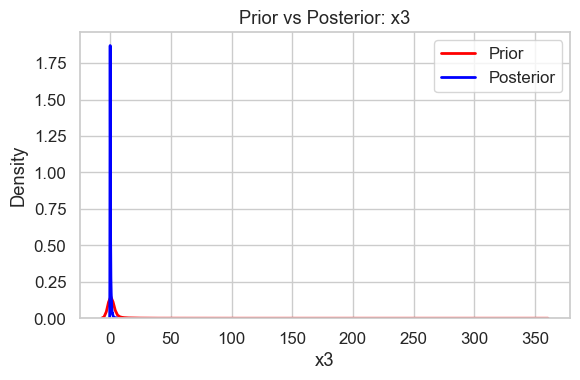

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


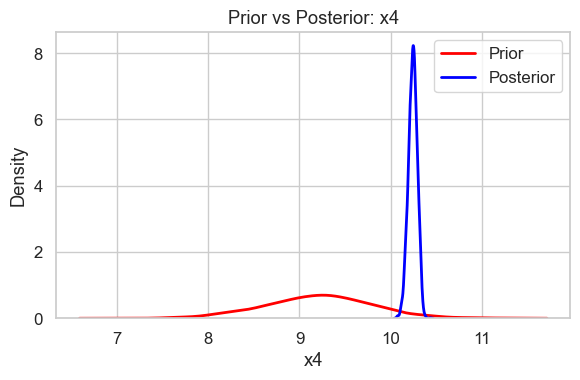

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


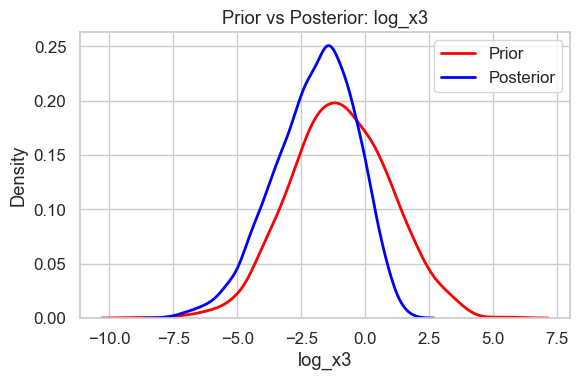

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


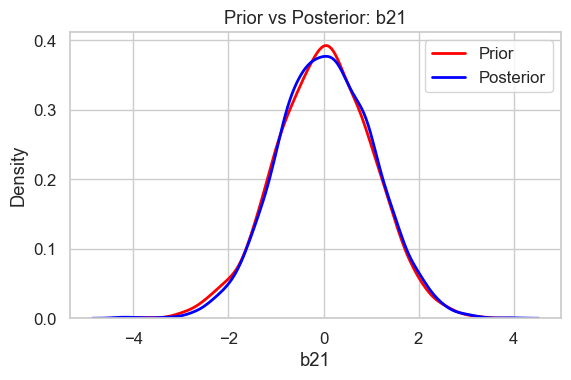

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


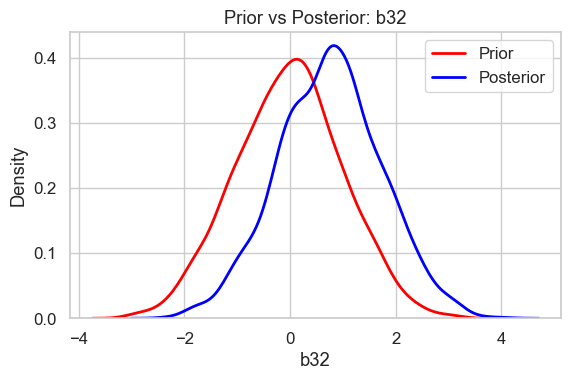

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


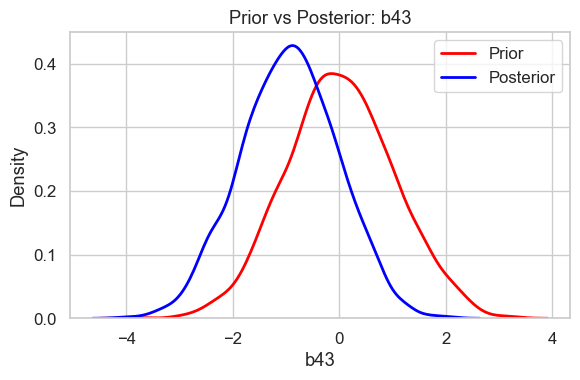

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


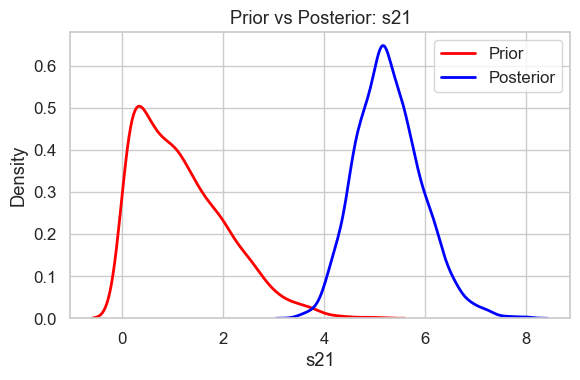

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


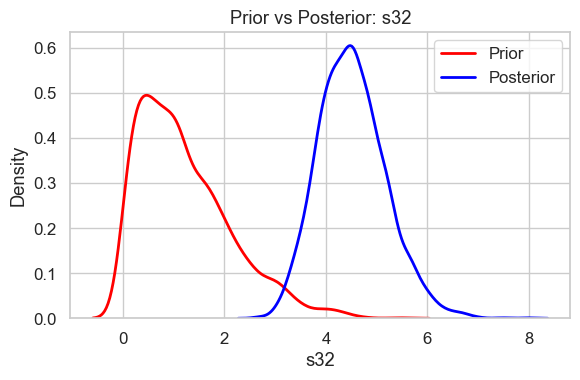

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


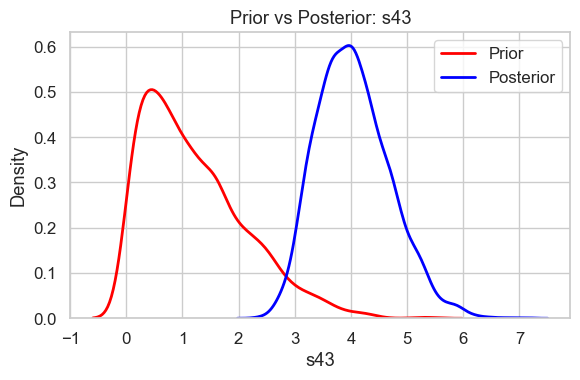

In [899]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3", "b21", "b32", "b43", "s21", "s32", "s43"]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [900]:
df.to_csv("posterior_samples_All_3.csv", index=False)
df_prior.to_csv("prior_samples_All_3.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv


## Experiment with different experiments

## Here we will have to narrow the bias priors so things dont get uddled up

## First with just Delta 21

In [901]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = numpyro.sample("x2", dist.Normal(5e4, 1e4))
    z3 = numpyro.sample("z3", dist.Normal(-1., 2.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(0., 1.))   # along ridge
    v = numpyro.sample("v", dist.Normal(0., 1.))   # across ridge
    x1 = 100*(0.4 + 0.1 * u)
    x4 = 9.2 + 0.5 * u + 0.3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    #f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    #f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    d21_pred = f2_pres_pred - f1_pres_pred
    #d32_pred = f3_pres_pred - f2_pres_pred
    #d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]
        d32_obs  = D[:, 1]
        d43_obs  = D[:, 2]
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    b21 = numpyro.sample("b21", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)
    #b32 = numpyro.sample("b32", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    #b43 = numpyro.sample("b43", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)

    m21 = d21_pred + b21
    #m32 = d32_pred + b32
    #m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    numpyro.deterministic("m21", m21)
    #numpyro.deterministic("m32", m32)
    #numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    s21 = numpyro.sample("s21", dist.HalfNormal(1.5))
    #s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    #s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    #numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    #numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [902]:
from numpyro.infer import Predictive
import jax.random as jr

# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

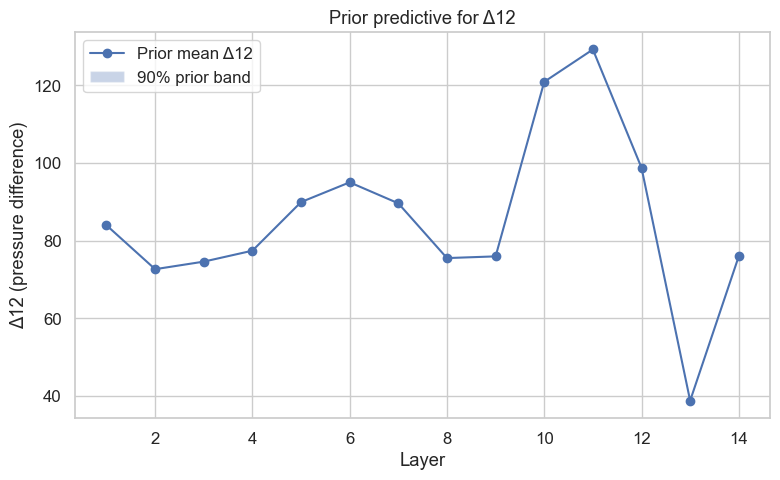

In [903]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


In [904]:
def run_nuts_calibration(
    F, D,
    seed=77, warmup=700, samples=1500, chains=2,
    target_accept=0.70, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


sample: 100%|█████████████████████████████████████████████████████████| 2200/2200 [02:24<00:00, 15.20it/s, 15 steps of size 1.30e-01. acc. prob=0.75]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       b21      0.01      1.00      0.02     -1.62      1.58    505.02      1.01
       s21      5.26      0.70      5.21      4.14      6.37    153.50      1.02
         u      2.19      0.20      2.17      1.83      2.53     33.69      1.06
         v      0.03      1.04      0.03     -1.73      1.60    364.19      1.01
        x2  53648.43  11266.46  53995.55  35069.24  74266.43     30.22      1.07
        z3     -0.97      1.96     -0.92     -4.19      2.14   1058.36      1.00

Number of divergences: 93


In [905]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Get raw samples from MCMC
samples = mcmc.get_samples()

# Reconstruct physical parameters
u_samples   = samples["u"]
v_samples   = samples["v"]
x2_samples  = samples["x2"]           # still in original scale
z3_samples  = samples["z3"]           # log(x3)
b21_samples = samples["b21"]
s21_samples = samples["s21"]

# Transformations to physical space
x1_samples  = 0.4 + 0.1 * u_samples      # matches model: x1 = 100*(0.4 + 0.1*u)
x2_phys     = x2_samples / 10.0                    # if GP used x2/10.
x3_samples  = jnp.exp(z3_samples)                  # x3 = exp(z3)
x4_samples  = 9.2 + 0.5 * u_samples + 0.3 * v_samples  # 9. + 1. * 0.5 * u + 0.3 * v 

# Convert to NumPy for pandas
x1_np  = np.asarray(x1_samples)
x2_np  = np.asarray(x2_phys)
x3_np  = np.asarray(x3_samples)
x4_np  = np.asarray(x4_samples)
u_np   = np.asarray(u_samples)
v_np   = np.asarray(v_samples)
z3_np  = np.asarray(z3_samples)
b21_np = np.asarray(b21_samples)
s21_np = np.asarray(s21_samples)


# Build DataFrame
df = pd.DataFrame({
    "x1":  x1_np,
    "x2":  x2_np,
    "x3": x3_np,
    "x4":  x4_np,
    "log_x3": z3_np,
    "b21": b21_np,
    "s21": s21_np,
})

# Optional: quick peek
print(df.head())


         x1           x2        x3         x4    log_x3       b21       s21
0  0.611490  6369.125977  0.093131  10.600452 -2.373751 -0.966904  4.044572
1  0.634986  4731.000977  0.738546  10.385028 -0.303072 -1.672315  7.842528
2  0.630927  5203.985352  0.511352  10.452270 -0.670697 -1.433458  6.188964
3  0.599212  6371.122070  1.221079  10.150568  0.199735  0.808909  4.481671
4  0.595591  6840.417969  2.513418  10.022891  0.921644  0.931268  4.264405


In [906]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b21_prior = prior_samples["b21"]
s21_prior = prior_samples["s21"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b21_p = np.asarray(b21_prior)
s21_p = np.asarray(s21_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b21":     b21_p,
    "s21":     s21_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b21       s21
0  0.457573  4957.405273  0.630753  9.137889 -0.460841  0.384647  1.292406
1  0.448919  5979.233887  0.029810  9.329538 -3.512919 -0.020355  1.047144
2  0.249714  5252.323242  2.335710  8.274053  0.848316 -0.175773  1.918535
3  0.438283  4336.837891  0.017581  9.670922 -4.040934  1.230969  0.291747
4  0.335213  5519.859375  0.153402  9.217848 -1.874691  0.007216  1.698671


In [907]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

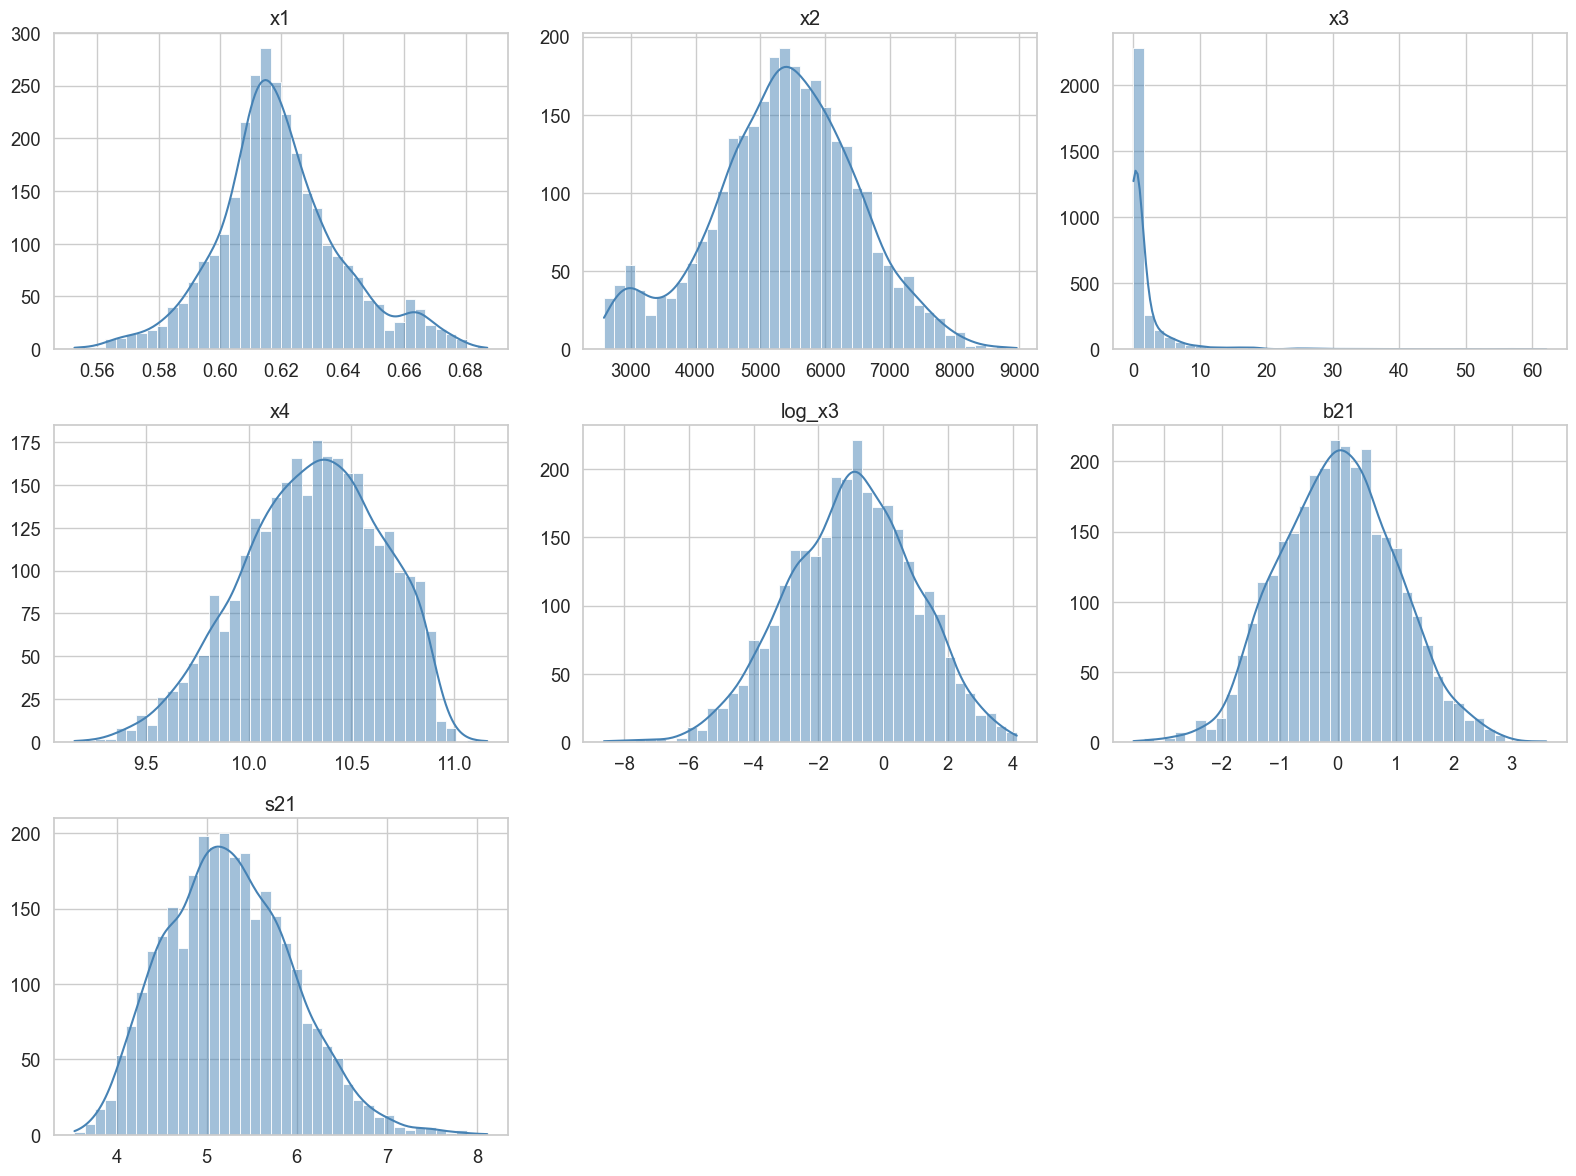

In [908]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

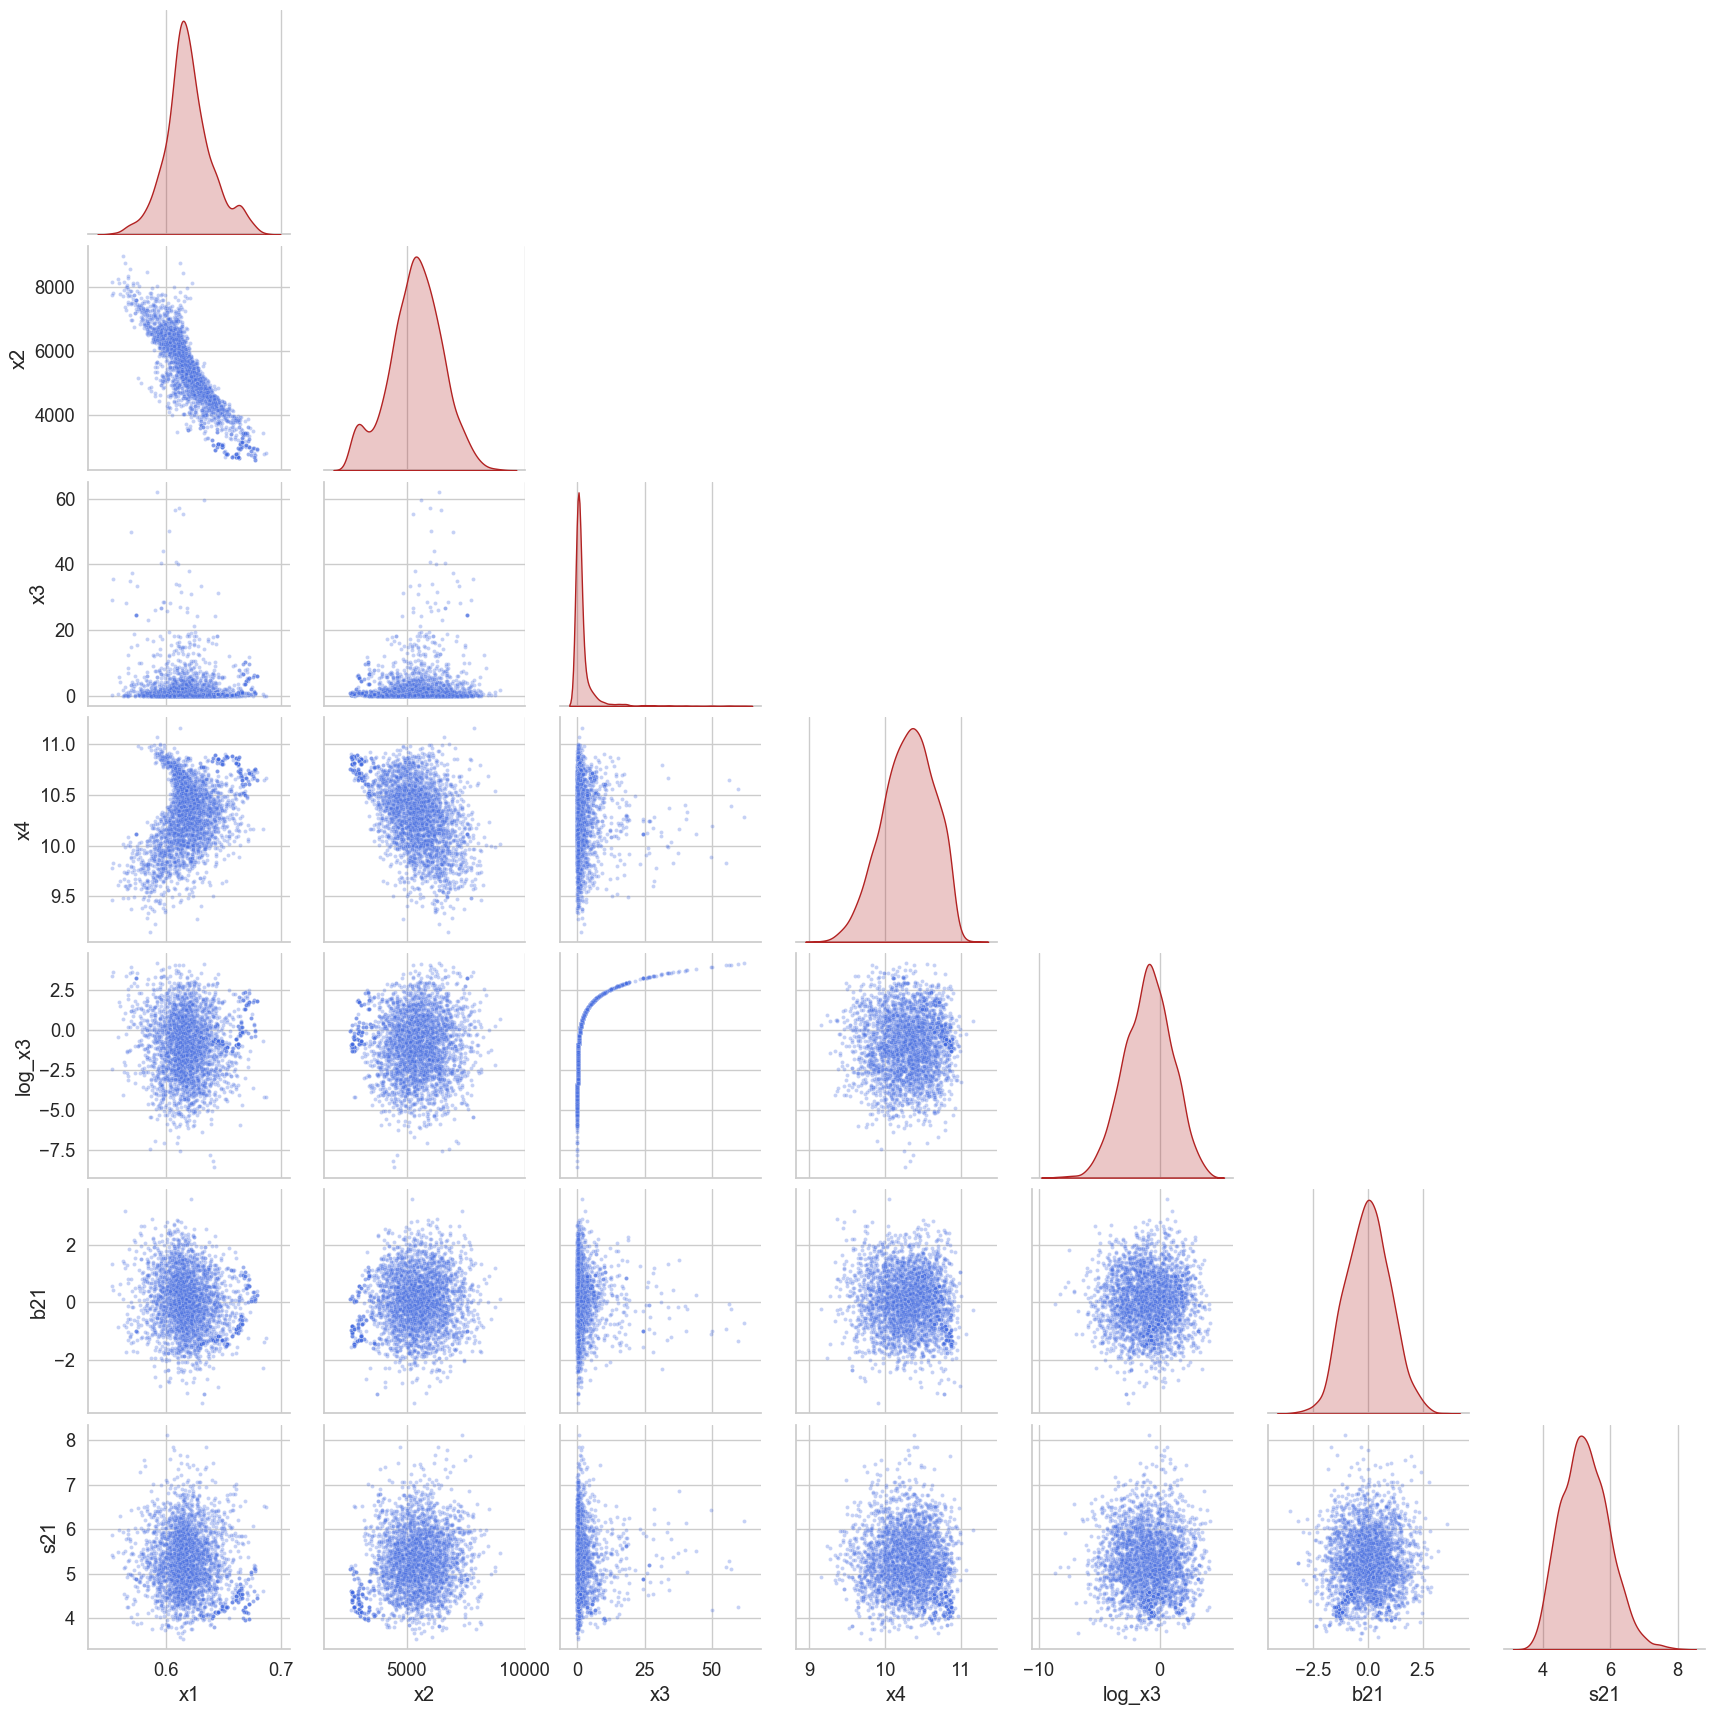

In [909]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="kde",
    diag_kws=dict(fill=True, color="firebrick"),
    plot_kws=dict(s=8, alpha=0.3, color="royalblue")
)
plt.show()


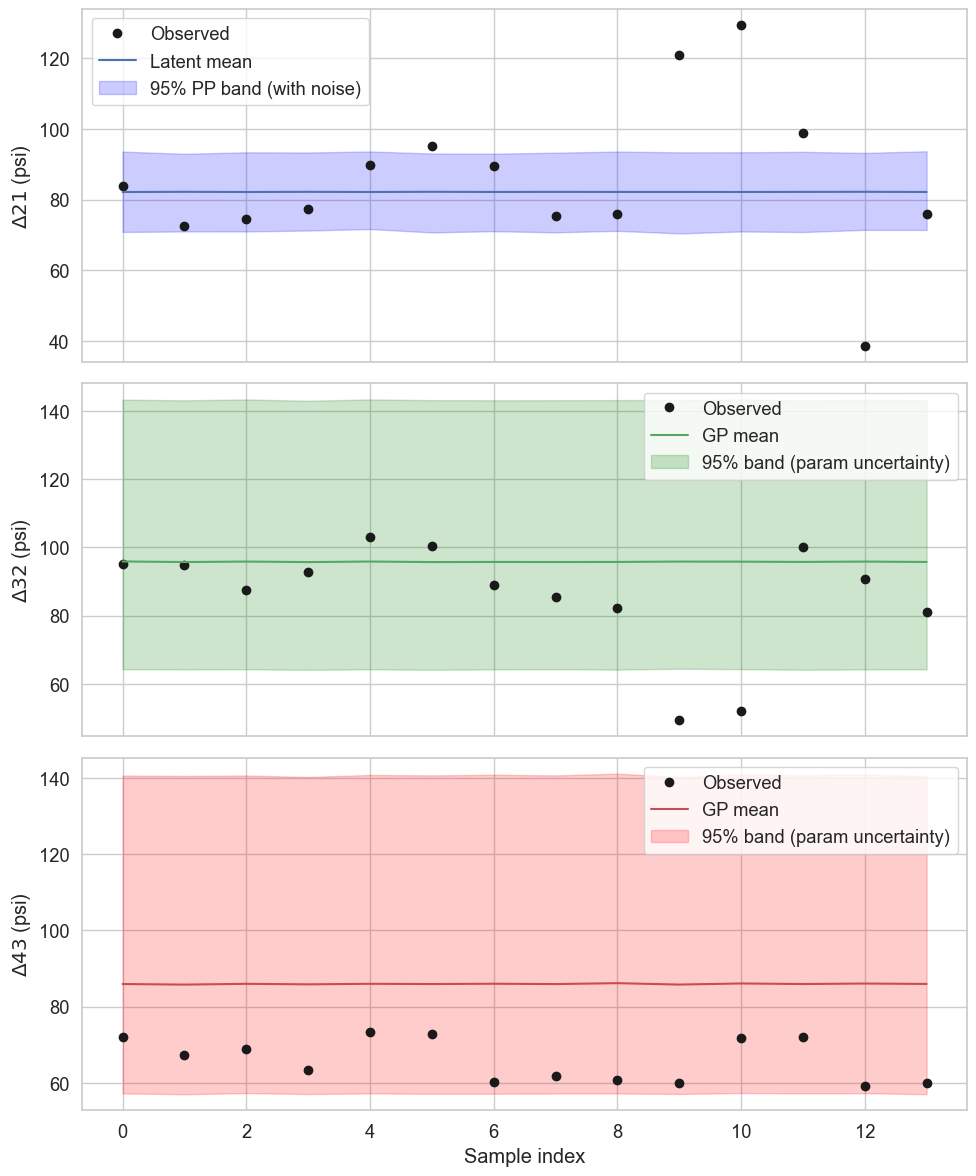

In [910]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values             # GP-scale x1 (as you stored it)
x2_s  = df["x2"].values * 10.0      # reverse earlier division, back to model scale if needed
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b21_s = df["b21"].values
s21_s = df["s21"].values

nsamp = len(df)

# ---------------------------------------------
# Compute posterior predictive for each sample
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    # Adjust these calls if your gp_flow_maps expects scaled x1/x2
    f1 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# Storage
m21_all = []
m32_all = []
m43_all = []

y21_all = []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i] / 10.0, x3_s[i], x4_s[i], F
    )

    # latent mean for Δ21 (has bias)
    m21 = d21 + b21_s[i]

    # for Δ32 and Δ43: mean predictions only from GP (no bias)
    m32 = d32
    m43 = d43

    # noisy posterior predictive ONLY for Δ21
    y21 = m21 + np.random.normal(0, s21_s[i], size=len(m21))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)
    y21_all.append(y21)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)
y21_all = np.vstack(y21_all)

# ---------------------------------------------
# Compute posterior predictive summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

# Δ21: we have both latent mean and noisy predictive
m21_mean, m21_lo, m21_hi = summarise(m21_all)
y21_mean, y21_lo, y21_hi = summarise(y21_all)

# Δ32, Δ43: only parameter-uncertainty bands from m32, m43
m32_mean, m32_lo, m32_hi = summarise(m32_all)
m43_mean, m43_lo, m43_hi = summarise(m43_all)

# Observed
d21_obs = D[:, 0]
d32_obs = D[:, 1]
d43_obs = D[:, 2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21: full posterior predictive
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="Latent mean")
ax.fill_between(x, y21_lo, y21_hi, color="blue", alpha=0.2, label="95% PP band (with noise)")
ax.set_ylabel(r"$\Delta 21$ (psi)")
ax.legend()

# Δ32: GP-only (no noise calibration)
ax = axes[1]
ax.plot(x, d32_obs, "ko", label="Observed")
ax.plot(x, m32_mean, "g-", label="GP mean")
ax.fill_between(x, m32_lo, m32_hi, color="green", alpha=0.2, label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 32$ (psi)")
ax.legend()

# Δ43: GP-only (no noise calibration)
ax = axes[2]
ax.plot(x, d43_obs, "ko", label="Observed")
ax.plot(x, m43_mean, "r-", label="GP mean")
ax.fill_between(x, m43_lo, m43_hi, color="red", alpha=0.2, label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 43$ (psi)")
ax.set_xlabel("Sample index")
ax.legend()

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


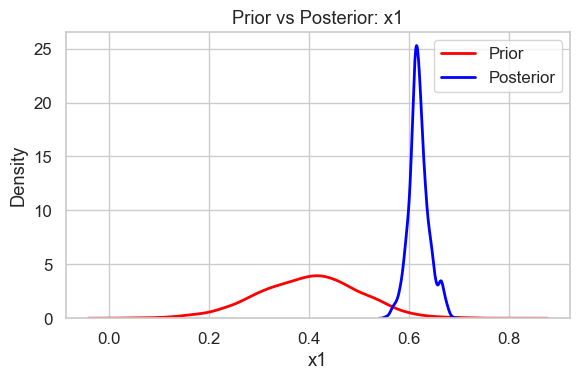

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


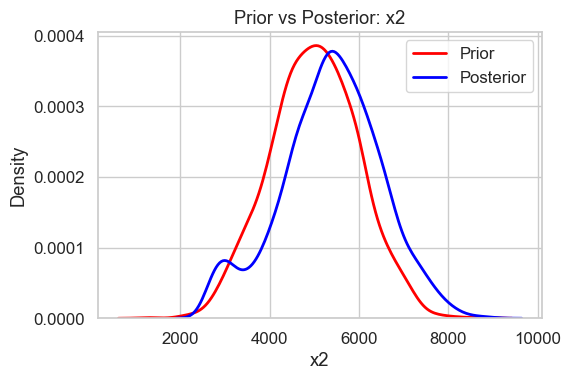

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


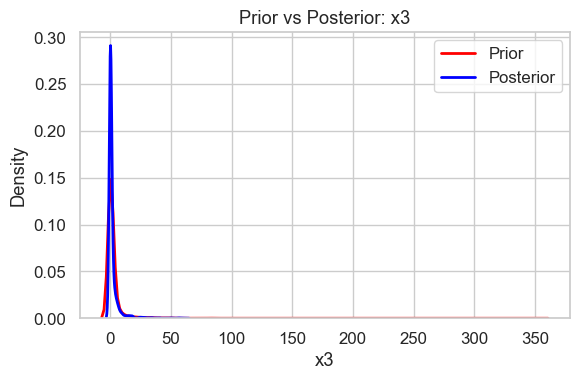

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


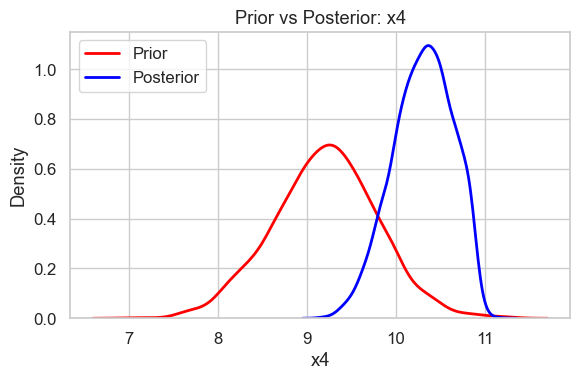

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


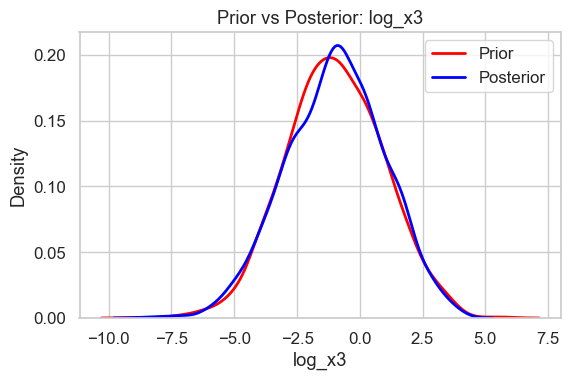

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


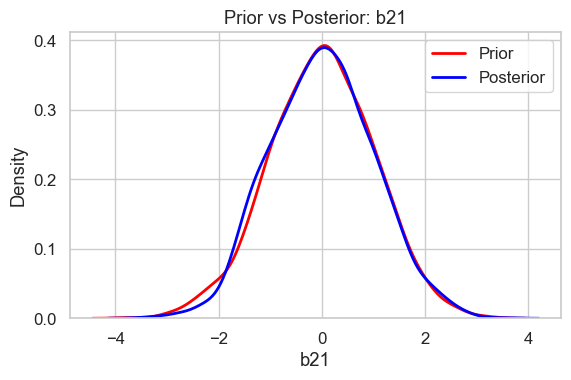

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


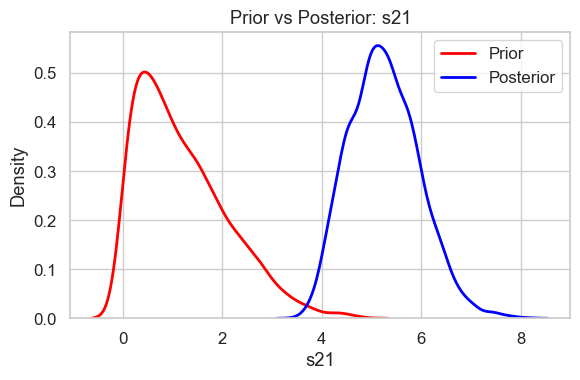

In [911]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3", "b21", "s21",]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [912]:
df.to_csv("posterior_samples_delta21.csv", index=False)
df_prior.to_csv("prior_samples_delta21.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv



## NExt with delta 43


In [913]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = numpyro.sample("x2", dist.Normal(5e4, 1e4))
    z3 = numpyro.sample("z3", dist.Normal(-1., 2.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(0., 1.))   # along ridge
    v = numpyro.sample("v", dist.Normal(0., 1.))   # across ridge
    x1 = 100*(0.4 + 0.1 * u)
    x4 = 9.2 + 0.5 * u + 0.3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    #f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    #f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    #d21_pred = f2_pres_pred - f1_pres_pred
    #d32_pred = f3_pres_pred - f2_pres_pred
    d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]
        d32_obs  = D[:, 1]
        d43_obs  = D[:, 2]
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    #b21 = numpyro.sample("b21", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    #b32 = numpyro.sample("b32", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    b43 = numpyro.sample("b43", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)

    #m21 = d21_pred + b21
    #m32 = d32_pred + b32
    m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    #numpyro.deterministic("m21", m21)
    #numpyro.deterministic("m32", m32)
    numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    #s21 = numpyro.sample("s21", dist.HalfNormal(1.5))
    #s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    #numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    #numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [914]:
from numpyro.infer import Predictive
import jax.random as jr

# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

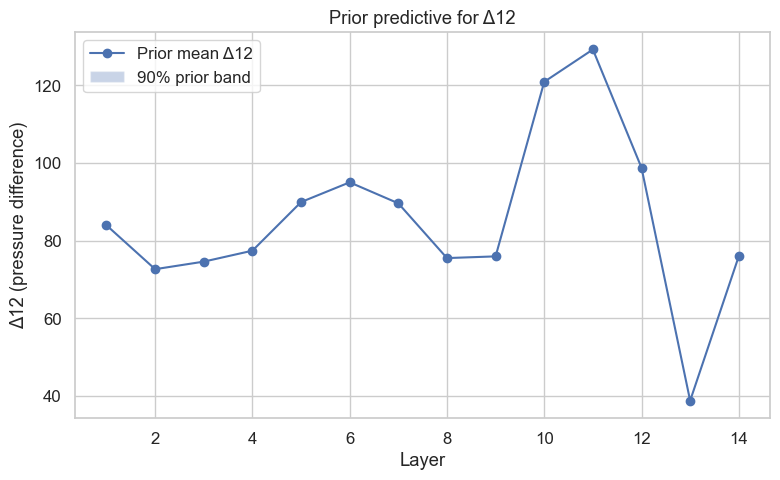

In [915]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


In [916]:
def run_nuts_calibration(
    F, D,
    seed=77, warmup=700, samples=1500, chains=2,
    target_accept=0.70, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


sample: 100%|█████████████████████████████████████████████████████████| 2200/2200 [12:31<00:00,  2.93it/s, 63 steps of size 3.50e-02. acc. prob=0.79]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       b43      0.01      1.01      0.00     -1.75      1.54   2085.02      1.00
       s43      3.91      0.67      3.82      2.77      4.92   1821.07      1.00
         u      1.99      0.27      2.00      1.58      2.46    877.95      1.00
         v      0.24      1.07      0.23     -1.52      1.94   1104.26      1.00
        x2  54759.93  10260.50  55154.67  38490.26  71867.18   1151.58      1.00
        z3     -0.88      2.01     -0.87     -4.14      2.53   1973.28      1.00

Number of divergences: 3


In [917]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Get raw samples from MCMC
samples = mcmc.get_samples()

# Reconstruct physical parameters
u_samples   = samples["u"]
v_samples   = samples["v"]
x2_samples  = samples["x2"]           # still in original scale
z3_samples  = samples["z3"]           # log(x3)
b43_samples = samples["b43"]
s43_samples = samples["s43"]

# Transformations to physical space
x1_samples  = 0.4 + 0.1 * u_samples      # matches model: x1 = 100*(0.4 + 0.1*u)
x2_phys     = x2_samples / 10.0                    # if GP used x2/10.
x3_samples  = jnp.exp(z3_samples)                  # x3 = exp(z3)
x4_samples  = 9.2 + 0.5 * u_samples + 0.3 * v_samples  # 9. + 1. * 0.5 * u + 0.3 * v 

# Convert to NumPy for pandas
x1_np  = np.asarray(x1_samples)
x2_np  = np.asarray(x2_phys)
x3_np  = np.asarray(x3_samples)
x4_np  = np.asarray(x4_samples)
u_np   = np.asarray(u_samples)
v_np   = np.asarray(v_samples)
z3_np  = np.asarray(z3_samples)
b43_np = np.asarray(b43_samples)
s43_np = np.asarray(s43_samples)


# Build DataFrame
df = pd.DataFrame({
    "x1":  x1_np,
    "x2":  x2_np,
    "x3": x3_np,
    "x4":  x4_np,
    "log_x3": z3_np,
    "b43": b43_np,
    "s43": s43_np,
})

# Optional: quick peek
print(df.head())


         x1           x2        x3         x4    log_x3       b43       s43
0  0.654284  3240.066162  1.174436  10.262815  0.160788  0.414891  5.068977
1  0.642719  5030.495605  0.108124   9.851028 -2.224473  1.119818  2.511835
2  0.637801  5305.674805  0.266539  10.004463 -1.322233  0.020377  2.814651
3  0.635357  5171.897461  2.113760   9.757738  0.748468 -0.486844  2.781864
4  0.589834  7498.853027  0.074726   9.959558 -2.593934  0.869027  4.841655


In [918]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b43_prior = prior_samples["b43"]
s43_prior = prior_samples["s43"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b43_p = np.asarray(b43_prior)
s43_p = np.asarray(s43_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b43":     b43_p,
    "s43":     s43_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b43       s43
0  0.457573  4957.405273  0.630753  9.137889 -0.460841  0.384647  1.292406
1  0.448919  5979.233887  0.029810  9.329538 -3.512919 -0.020355  1.047144
2  0.249714  5252.323242  2.335710  8.274053  0.848316 -0.175773  1.918535
3  0.438283  4336.837891  0.017581  9.670922 -4.040934  1.230969  0.291747
4  0.335213  5519.859375  0.153402  9.217848 -1.874691  0.007216  1.698671


In [919]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

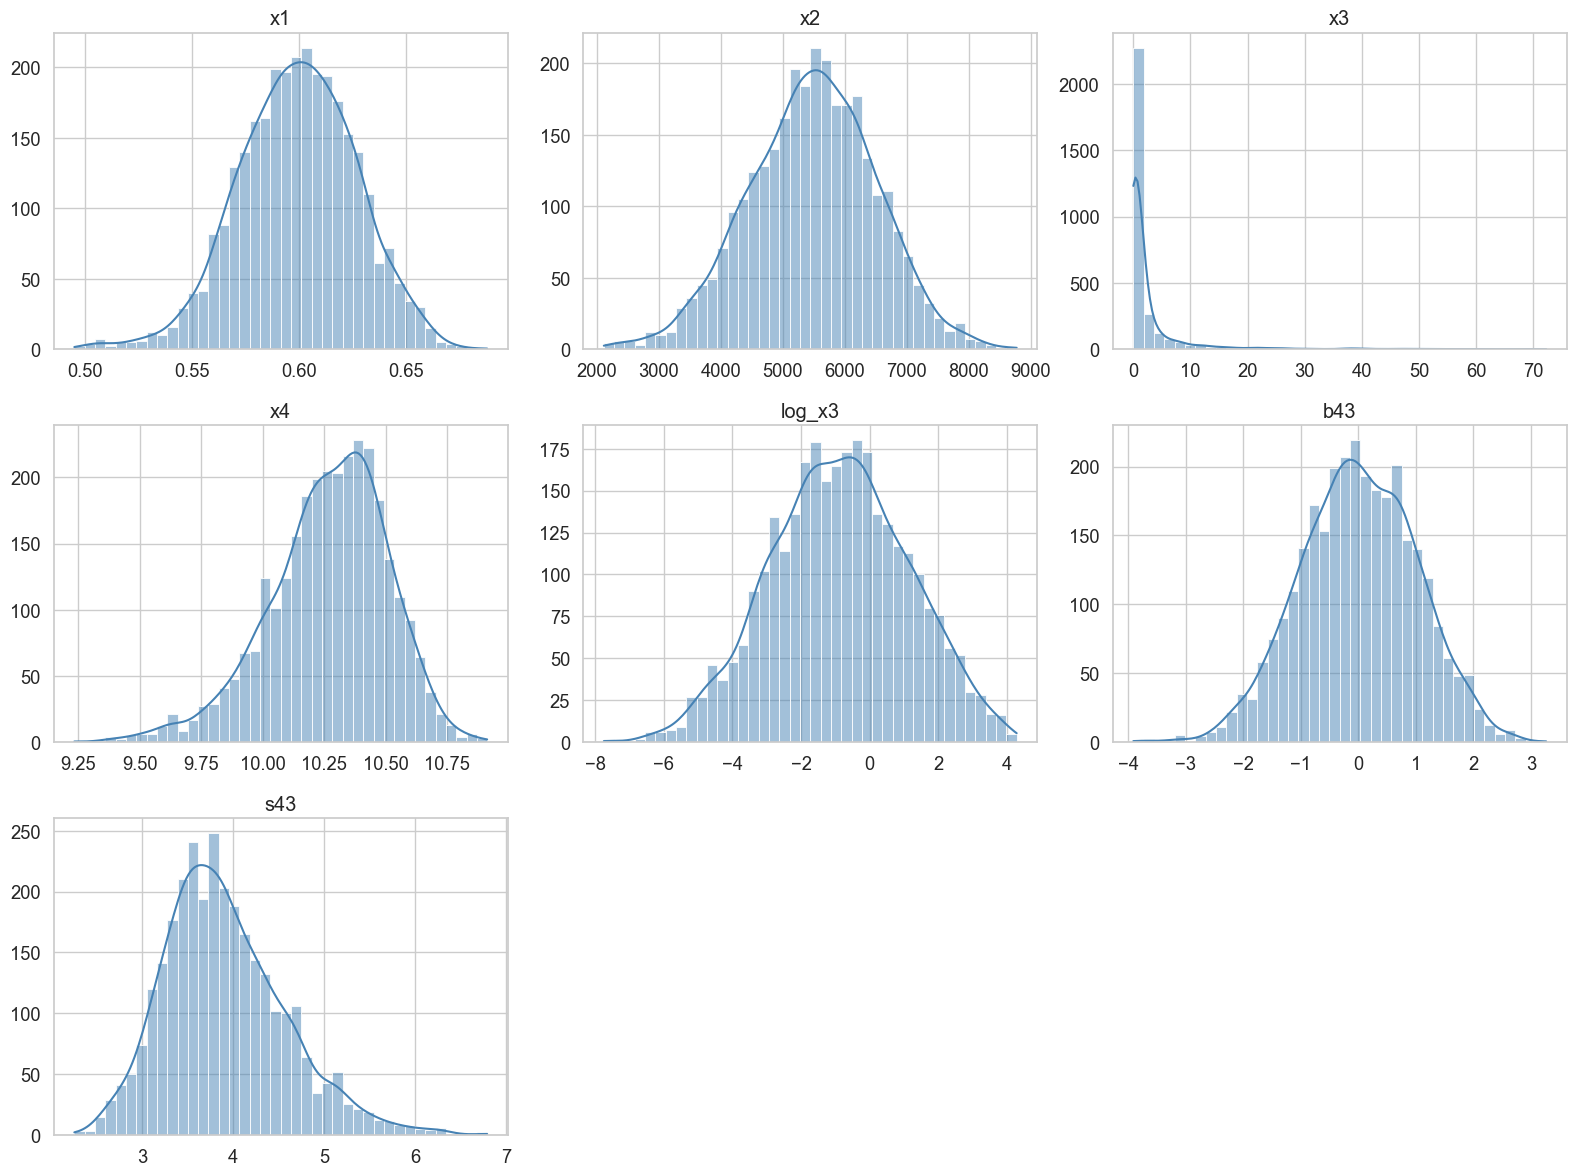

In [920]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

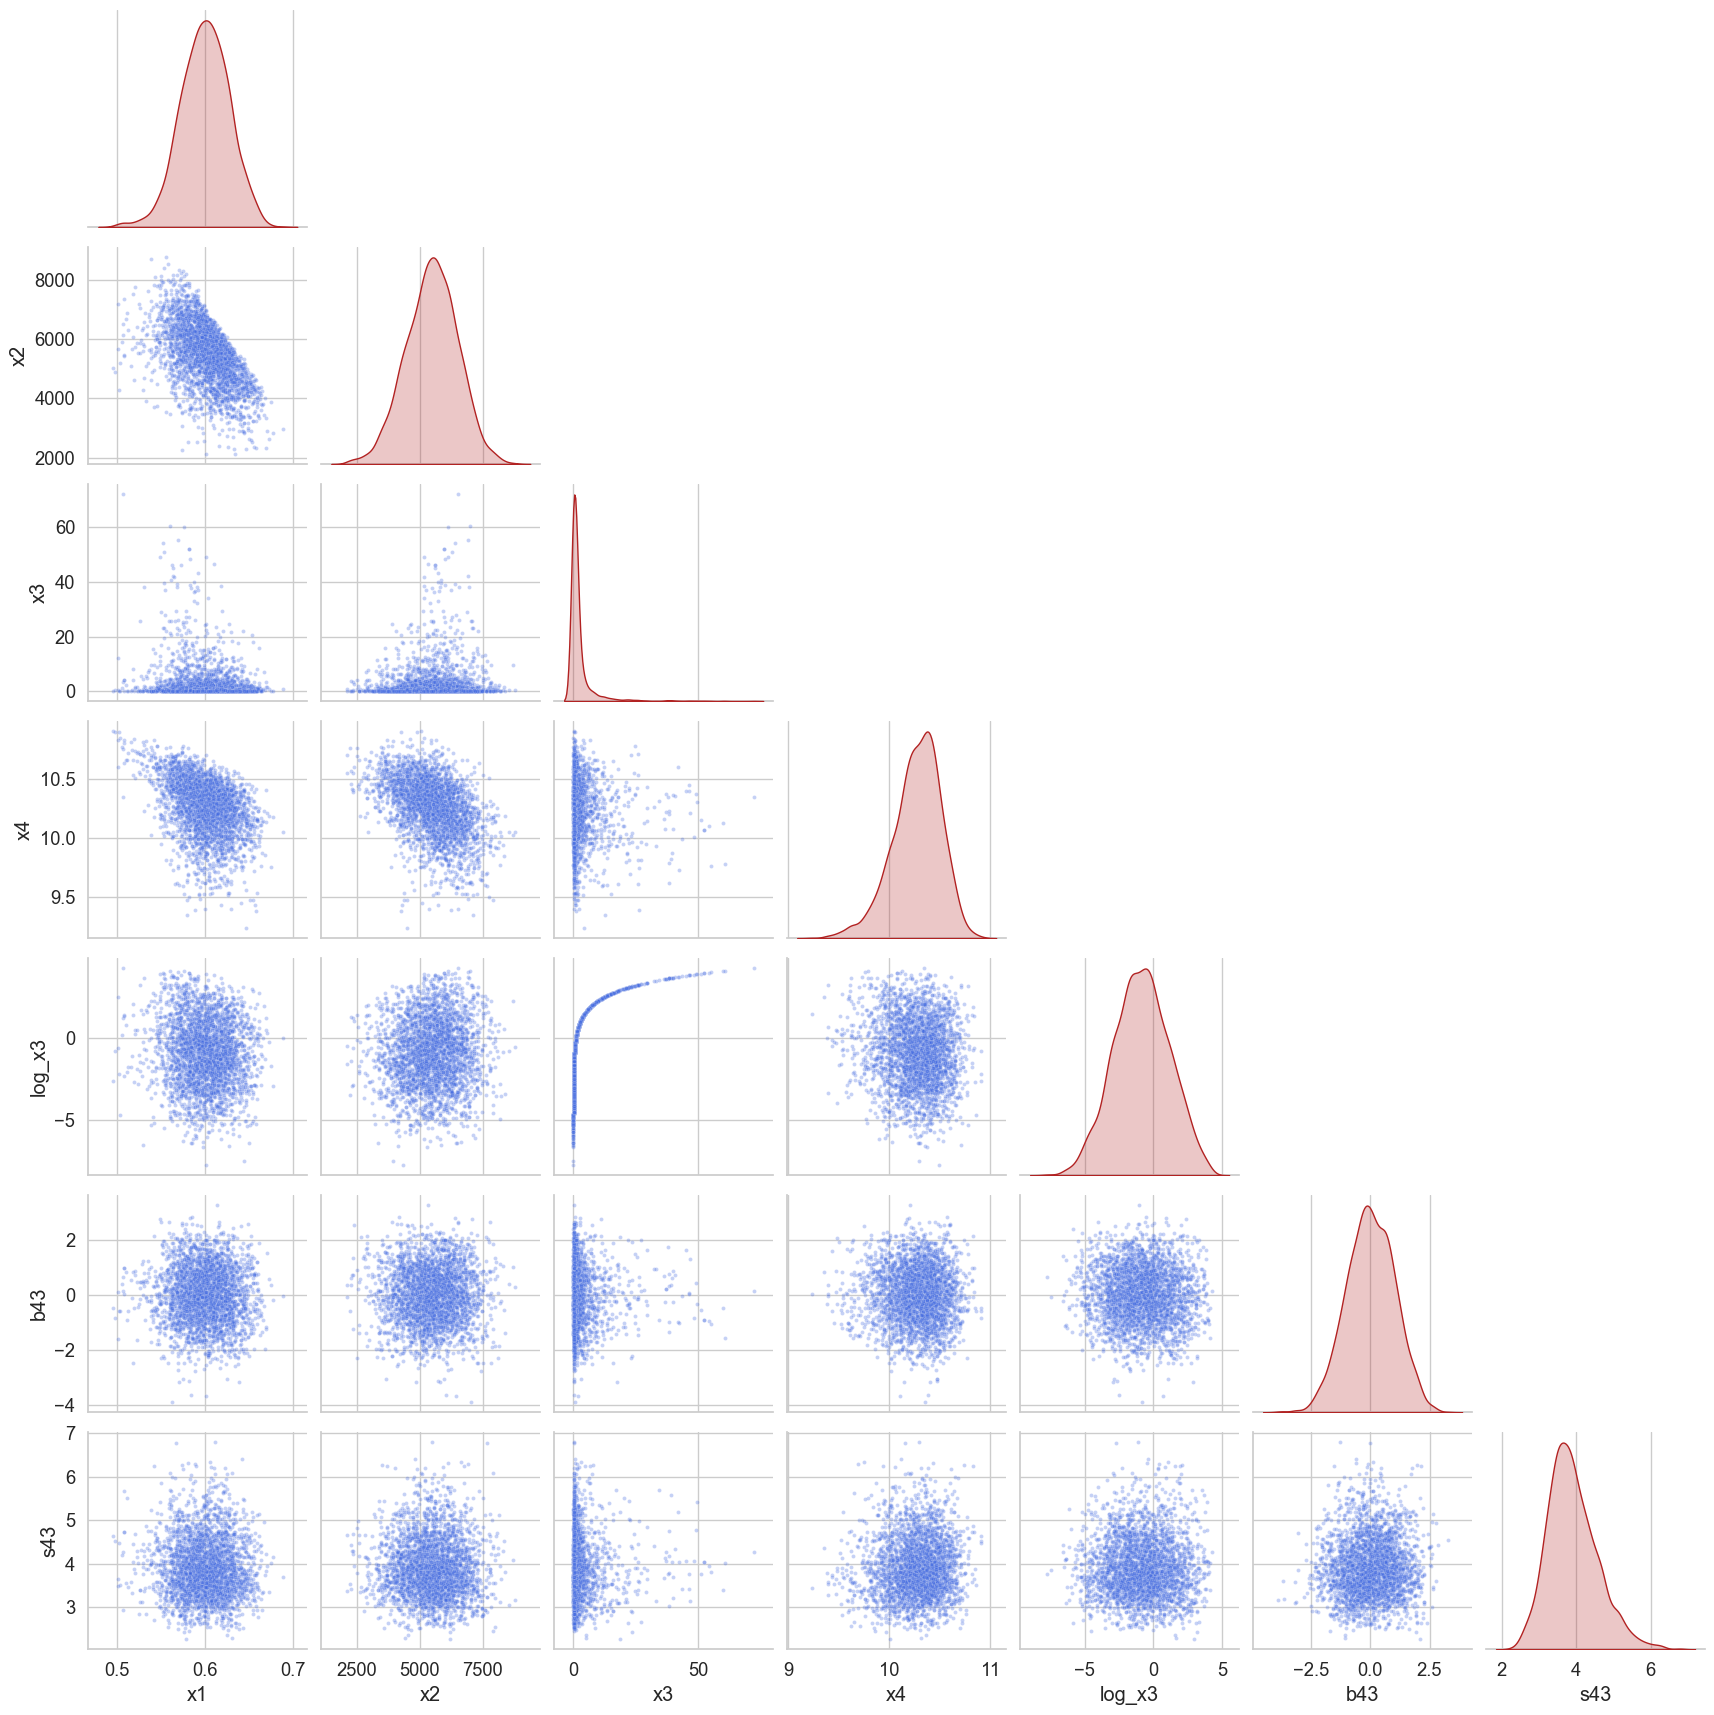

In [921]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="kde",
    diag_kws=dict(fill=True, color="firebrick"),
    plot_kws=dict(s=8, alpha=0.3, color="royalblue")
)
plt.show()


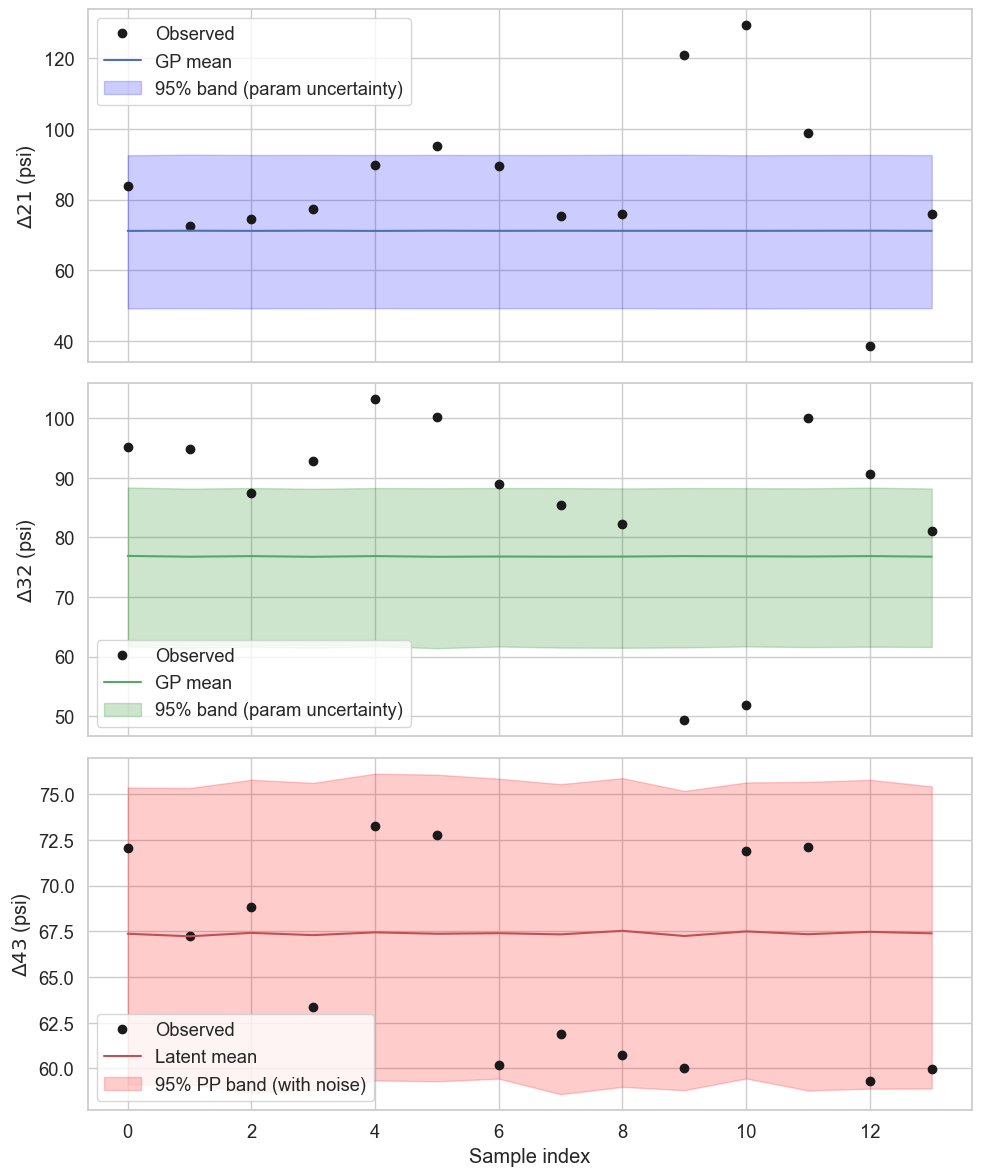

In [922]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values             # GP-scale x1 (as you stored it)
x2_s  = df["x2"].values * 10.0      # reverse earlier division, back to model scale if needed
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b43_s = df["b43"].values
s43_s = df["s43"].values

nsamp = len(df)

# ---------------------------------------------
# Compute posterior predictive for each sample
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    # Adjust these calls if your gp_flow_maps expects scaled x1/x2
    f1 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# Storage
m21_all = []
m32_all = []
m43_all = []
y43_all = []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i] / 10.0, x3_s[i], x4_s[i], F
    )

    # Δ21 and Δ32: mean predictions only from GP (no bias)
    m21 = d21
    m32 = d32

    # Δ43: latent mean has bias
    m43 = d43 + b43_s[i]

    # noisy posterior predictive ONLY for Δ43
    y43 = m43 + np.random.normal(0, s43_s[i], size=len(m43))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)
    y43_all.append(y43)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)
y43_all = np.vstack(y43_all)

# ---------------------------------------------
# Compute posterior predictive summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

# Δ43: we have both latent mean and noisy predictive
m43_mean, m43_lo, m43_hi = summarise(m43_all)
y43_mean, y43_lo, y43_hi = summarise(y43_all)

# Δ21, Δ32: only parameter-uncertainty bands from m21, m32
m21_mean, m21_lo, m21_hi = summarise(m21_all)
m32_mean, m32_lo, m32_hi = summarise(m32_all)

# Observed
d21_obs = D[:, 0]
d32_obs = D[:, 1]
d43_obs = D[:, 2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21: GP-only (no noise calibration)
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="GP mean")
ax.fill_between(x, m21_lo, m21_hi, color="blue", alpha=0.2,
                label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 21$ (psi)")
ax.legend()

# Δ32: GP-only (no noise calibration)
ax = axes[1]
ax.plot(x, d32_obs, "ko", label="Observed")
ax.plot(x, m32_mean, "g-", label="GP mean")
ax.fill_between(x, m32_lo, m32_hi, color="green", alpha=0.2,
                label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 32$ (psi)")
ax.legend()

# Δ43: full posterior predictive
ax = axes[2]
ax.plot(x, d43_obs, "ko", label="Observed")
ax.plot(x, m43_mean, "r-", label="Latent mean")
ax.fill_between(x, y43_lo, y43_hi, color="red", alpha=0.2,
                label="95% PP band (with noise)")
ax.set_ylabel(r"$\Delta 43$ (psi)")
ax.set_xlabel("Sample index")
ax.legend()

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


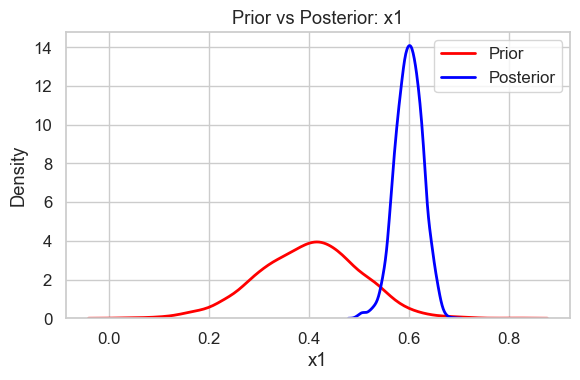

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


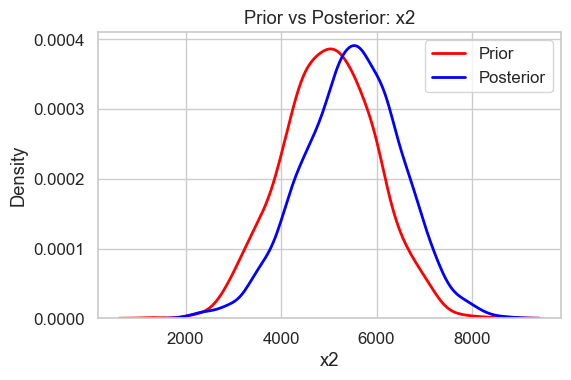

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


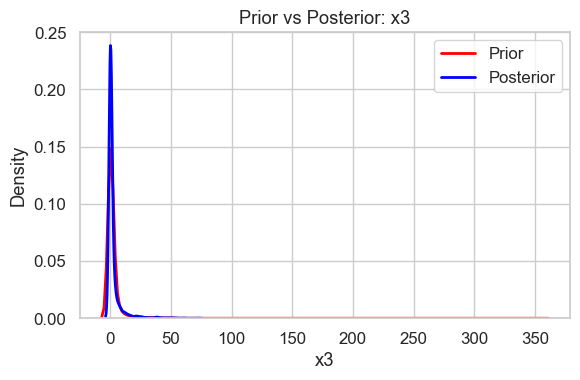

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


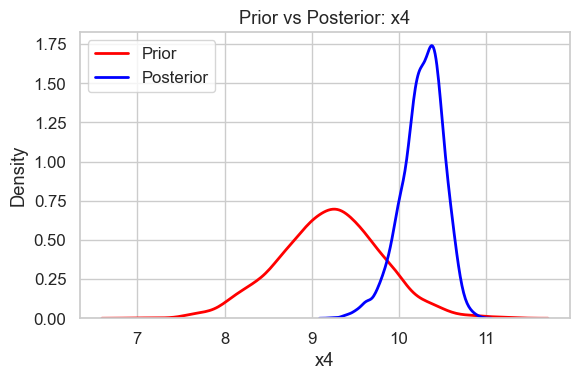

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


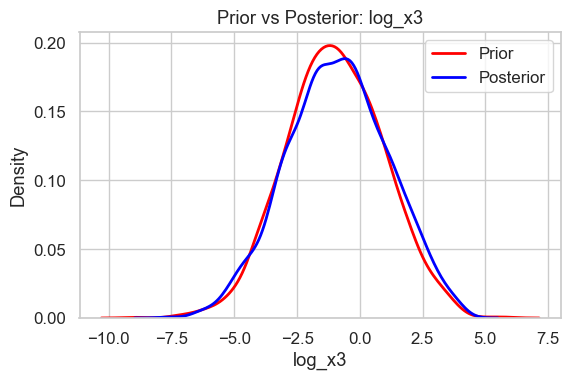

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


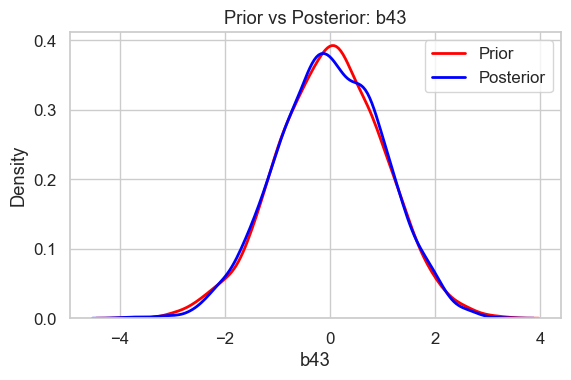

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


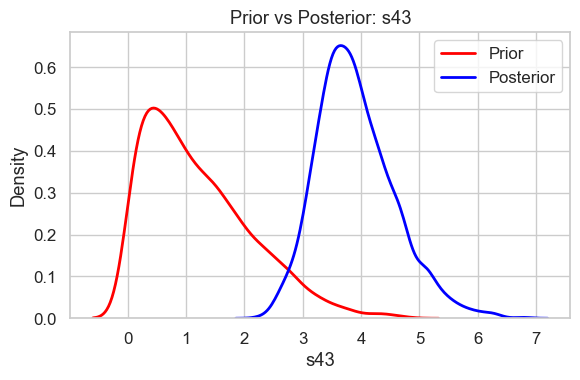

In [923]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3", "b43", "s43",]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [924]:
df.to_csv("posterior_samples_delta43.csv", index=False)
df_prior.to_csv("prior_samples_delta43.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv



## Make posterior comparisons

In [926]:
import pandas as pd

# ---- Load prior ----
df_prior = pd.read_csv("prior_samples_delta43.csv")

# ---- Load posteriors ----
post21 = pd.read_csv("posterior_samples_delta21.csv")
post43 = pd.read_csv("posterior_samples_delta43.csv")
postALL = pd.read_csv("posterior_samples_All_3.csv")

print("Prior shape:", df_prior.shape)
print("Δ21 posterior shape:", post21.shape)
print("Δ43 posterior shape:", post43.shape)
print("ALL Δ posterior shape:", postALL.shape)

print("\nColumn names:")
print("Prior:", df_prior.columns.tolist())
print("Δ21 :", post21.columns.tolist())
print("Δ43 :", post43.columns.tolist())
print("ALL :", postALL.columns.tolist())


Prior shape: (2000, 7)
Δ21 posterior shape: (3000, 7)
Δ43 posterior shape: (3000, 7)
ALL Δ posterior shape: (3000, 11)

Column names:
Prior: ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b43', 's43']
Δ21 : ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b21', 's21']
Δ43 : ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b43', 's43']
ALL : ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b21', 'b32', 'b43', 's21', 's32', 's43']


Loaded Δ21 posterior: (3000, 7)
Loaded Δ43 posterior: (3000, 7)
Loaded ALL posterior: (3000, 11)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


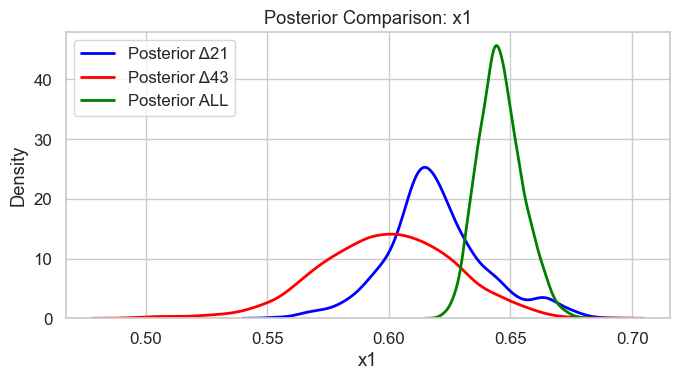

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


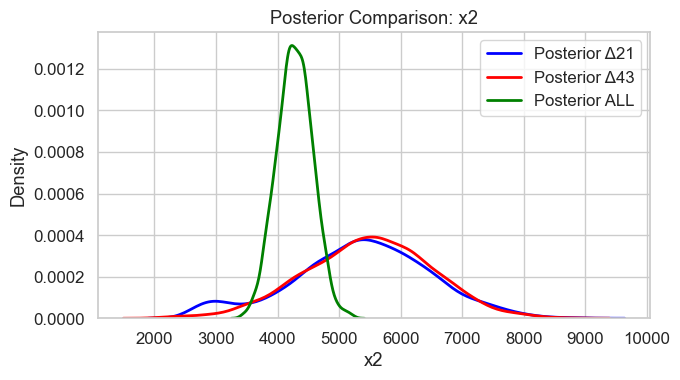

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


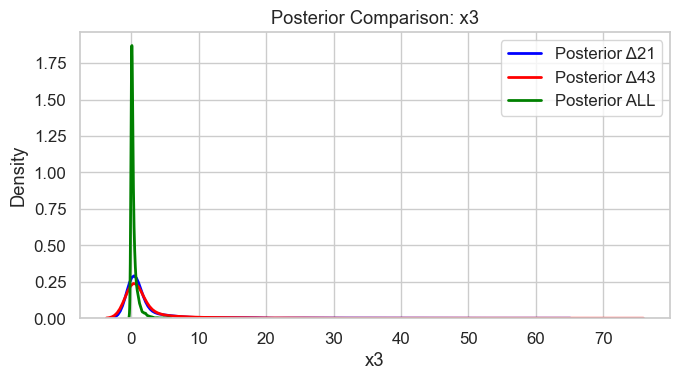

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


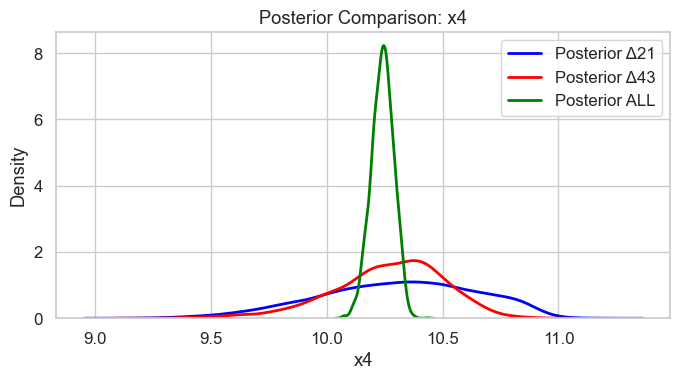

In [928]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# Load posterior samples
# -----------------------------------------
post21 = pd.read_csv("posterior_samples_delta21.csv")
post43 = pd.read_csv("posterior_samples_delta43.csv")
postALL = pd.read_csv("posterior_samples_All_3.csv")    # <-- NEW

params = ["x1", "x2", "x3", "x4"]

print("Loaded Δ21 posterior:", post21.shape)
print("Loaded Δ43 posterior:", post43.shape)
print("Loaded ALL posterior:", postALL.shape)

# -----------------------------------------
# KDE comparison plots (3-way)
# -----------------------------------------
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

colors = {
    "Δ21": "blue",
    "Δ43": "red",
    "ALL": "green"
}

for p in params:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(post21[p], label="Posterior Δ21", color=colors["Δ21"], lw=2)
    sns.kdeplot(post43[p], label="Posterior Δ43", color=colors["Δ43"], lw=2)
    sns.kdeplot(postALL[p], label="Posterior ALL", color=colors["ALL"], lw=2)
    
    plt.title(f"Posterior Comparison: {p}")
    plt.xlabel(p)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

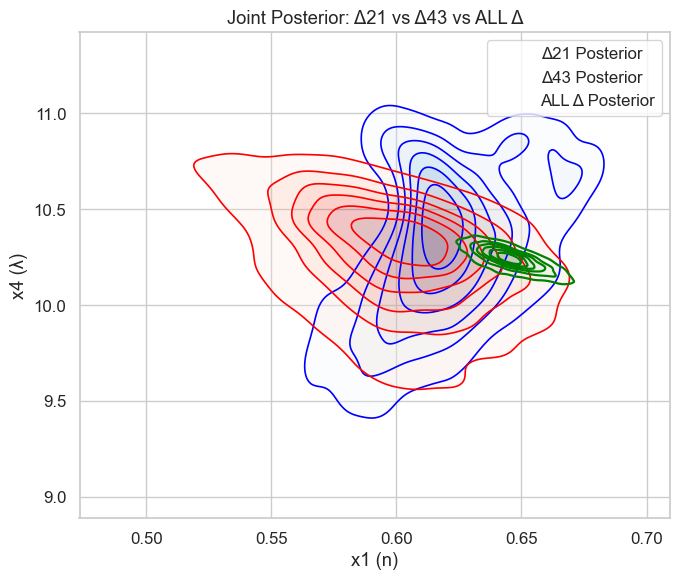

In [933]:
plt.figure(figsize=(7,6))

# ============================
# Δ21 (blue)
# ============================
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    cmap="Blues", levels=7, fill=True, alpha=0.25, thresh=0.05
)
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    color="blue", levels=7, fill=False, linewidths=1.2, label="Δ21 Posterior"
)

# ============================
# Δ43 (red)
# ============================
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    cmap="Reds", levels=7, fill=True, alpha=0.25, thresh=0.05
)
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    color="red", levels=7, fill=False, linewidths=1.2, label="Δ43 Posterior"
)

# ============================
# ALL Δ's (green)
# ============================
sns.kdeplot(
    x=postALL["x1"], y=postALL["x4"],
    cmap="Greens", levels=7, fill=True, alpha=0.20, thresh=0.05
)
sns.kdeplot(
    x=postALL["x1"], y=postALL["x4"],
    color="green", levels=7, fill=False, linewidths=1.6, label="ALL Δ Posterior"
)

# ============================
# Formatting
# ============================
plt.xlabel("x1 (n)")
plt.ylabel("x4 (λ)")
plt.title("Joint Posterior: Δ21 vs Δ43 vs ALL Δ")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(7,6))

# -------------------------
# PRIOR (gray contours)
# -------------------------
sns.kdeplot(
    x=df_prior["x1"], y=df_prior["x4"],
    color="black",
    levels=6,
    fill=False,
    linestyle="--",
    linewidths=1.3,
    label="Prior"
)

# -------------------------
# Δ21 (blue)
# -------------------------
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    cmap="Blues", levels=7, fill=True, alpha=0.30, thresh=0.05
)
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    color="blue", levels=7, fill=False, linewidths=1.4,
    label="Δ21 posterior"
)

# -------------------------
# Δ43 (red)
# -------------------------
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    cmap="Reds", levels=7, fill=True, alpha=0.30, thresh=0.05
)
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    color="red", levels=7, fill=False, linewidths=1.4,
    label="Δ43 posterior"
)

plt.xlabel("x1")
plt.ylabel("x4")
plt.title("Joint Posterior: Δ21 vs Δ43 vs Prior")
plt.legend()
plt.tight_layout()
plt.show()


## Next with delta 43 and delta 21

In [937]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = numpyro.sample("x2", dist.Normal(5e4, 1e4))
    z3 = numpyro.sample("z3", dist.Normal(-1., 2.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(0., 1.))   # along ridge
    v = numpyro.sample("v", dist.Normal(0., 1.))   # across ridge
    x1 = 100*(0.4 + 0.1 * u)
    x4 = 9.2 + 0.5 * u + 0.3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    d21_pred = f2_pres_pred - f1_pres_pred
    #d32_pred = f3_pres_pred - f2_pres_pred
    d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]
        d32_obs  = D[:, 1]
        d43_obs  = D[:, 2]
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    b21 = numpyro.sample("b21", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)
    #b32 = numpyro.sample("b32", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    b43 = numpyro.sample("b43", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)

    m21 = d21_pred + b21
    #m32 = d32_pred + b32
    m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    numpyro.deterministic("m21", m21)
    #numpyro.deterministic("m32", m32)
    numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    s21 = numpyro.sample("s21", dist.HalfNormal(1.5))
    #s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    #numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [939]:


# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

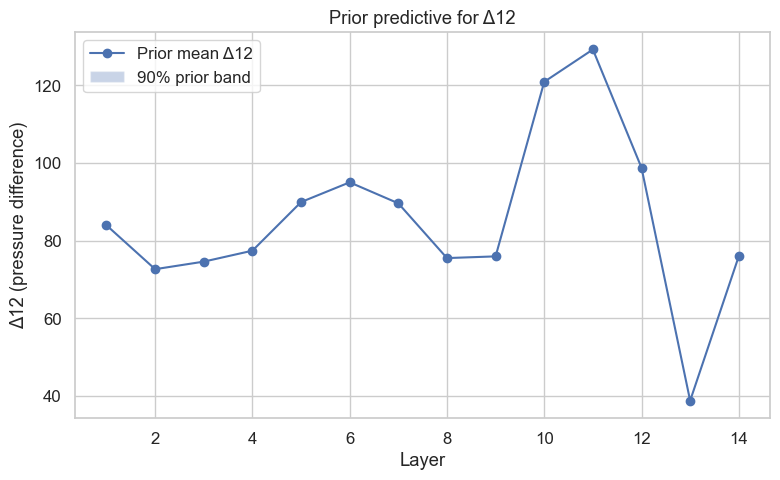

In [940]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


In [941]:
def run_nuts_calibration(
    F, D,
    seed=77, warmup=700, samples=1500, chains=2,
    target_accept=0.70, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


sample: 100%|█████████████████████████████████████████████████████████| 2200/2200 [10:19<00:00,  3.55it/s, 63 steps of size 6.65e-02. acc. prob=0.74]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       b21      0.04      0.99      0.05     -1.58      1.66   1860.74      1.00
       b43      0.05      1.02      0.08     -1.59      1.77   2236.58      1.00
       s21      5.29      0.67      5.24      4.17      6.32   2172.85      1.00
       s43      3.91      0.63      3.85      2.82      4.86   2087.53      1.00
         u      2.18      0.18      2.18      1.88      2.48   1040.76      1.00
         v     -0.70      0.40     -0.62     -1.19     -0.16    493.60      1.00
        x2  55756.53   8457.45  55530.84  41986.95  69710.38   1087.67      1.00
        z3     -0.77      2.02     -0.77     -3.81      2.83   1036.55      1.00

Number of divergences: 5


In [942]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Get raw samples from MCMC
samples = mcmc.get_samples()

# Reconstruct physical parameters
u_samples   = samples["u"]
v_samples   = samples["v"]
x2_samples  = samples["x2"]           # still in original scale
z3_samples  = samples["z3"]           # log(x3)
b43_samples = samples["b43"]
b21_samples = samples["b21"]
s21_samples = samples["s21"]
s43_samples = samples["s43"]

# Transformations to physical space
x1_samples  = 0.4 + 0.1 * u_samples      # matches model: x1 = 100*(0.4 + 0.1*u)
x2_phys     = x2_samples / 10.0                    # if GP used x2/10.
x3_samples  = jnp.exp(z3_samples)                  # x3 = exp(z3)
x4_samples  = 9.2 + 0.5 * u_samples + 0.3 * v_samples  # 9. + 1. * 0.5 * u + 0.3 * v 

# Convert to NumPy for pandas
x1_np  = np.asarray(x1_samples)
x2_np  = np.asarray(x2_phys)
x3_np  = np.asarray(x3_samples)
x4_np  = np.asarray(x4_samples)
u_np   = np.asarray(u_samples)
v_np   = np.asarray(v_samples)
z3_np  = np.asarray(z3_samples)
b21_np = np.asarray(b21_samples)
b43_np = np.asarray(b43_samples)
s21_np = np.asarray(s21_samples)
s43_np = np.asarray(s43_samples)


# Build DataFrame
df = pd.DataFrame({
    "x1":  x1_np,
    "x2":  x2_np,
    "x3": x3_np,
    "x4":  x4_np,
    "log_x3": z3_np,
    "b21": b21_np,
    "b43": b43_np,
    "s21": s21_np,
    "s43": s43_np,
})

# Optional: quick peek
print(df.head())


         x1           x2        x3         x4    log_x3       b21       b43  \
0  0.616437  5410.052246  0.423834  10.165322 -0.858413 -0.169333  0.169509   
1  0.605365  6275.506836  0.038419  10.017399 -3.259212  0.242757 -0.629239   
2  0.610749  6002.097656  1.380551  10.082264  0.322482 -1.897542 -1.057196   
3  0.638240  4654.791992  0.067066  10.147166 -2.702072 -1.275399  0.029746   
4  0.614985  5540.802246  1.072314  10.189867  0.069818  1.675234  0.552549   

        s21       s43  
0  5.499002  4.810949  
1  4.550429  2.536696  
2  3.781868  3.489031  
3  4.425895  3.471337  
4  6.442704  3.492726  


In [944]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b21_prior = prior_samples["b21"]
b43_prior = prior_samples["b43"]
s21_prior = prior_samples["s21"]
s43_prior = prior_samples["s43"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b21_p = np.asarray(b21_prior)
b43_p = np.asarray(b43_prior)
s21_p = np.asarray(s21_prior)
s43_p = np.asarray(s43_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b43":     b43_p,
    "b21":     b21_p,
    "s21":     s21_p,
    "s43":     s43_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b43       b21  \
0  0.457573  4957.405273  0.630753  9.137889 -0.460841  0.861604  0.384647   
1  0.448919  5979.233887  0.029810  9.329538 -3.512919 -0.698096 -0.020355   
2  0.249714  5252.323242  2.335710  8.274053  0.848316  1.279024 -0.175773   
3  0.438283  4336.837891  0.017581  9.670922 -4.040934 -0.194498  1.230969   
4  0.335213  5519.859375  0.153402  9.217848 -1.874691  1.132447  0.007216   

        s21       s43  
0  0.375014  0.303161  
1  1.086547  1.384874  
2  4.516365  1.591959  
3  1.700570  2.448206  
4  1.935235  0.266113  


In [945]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

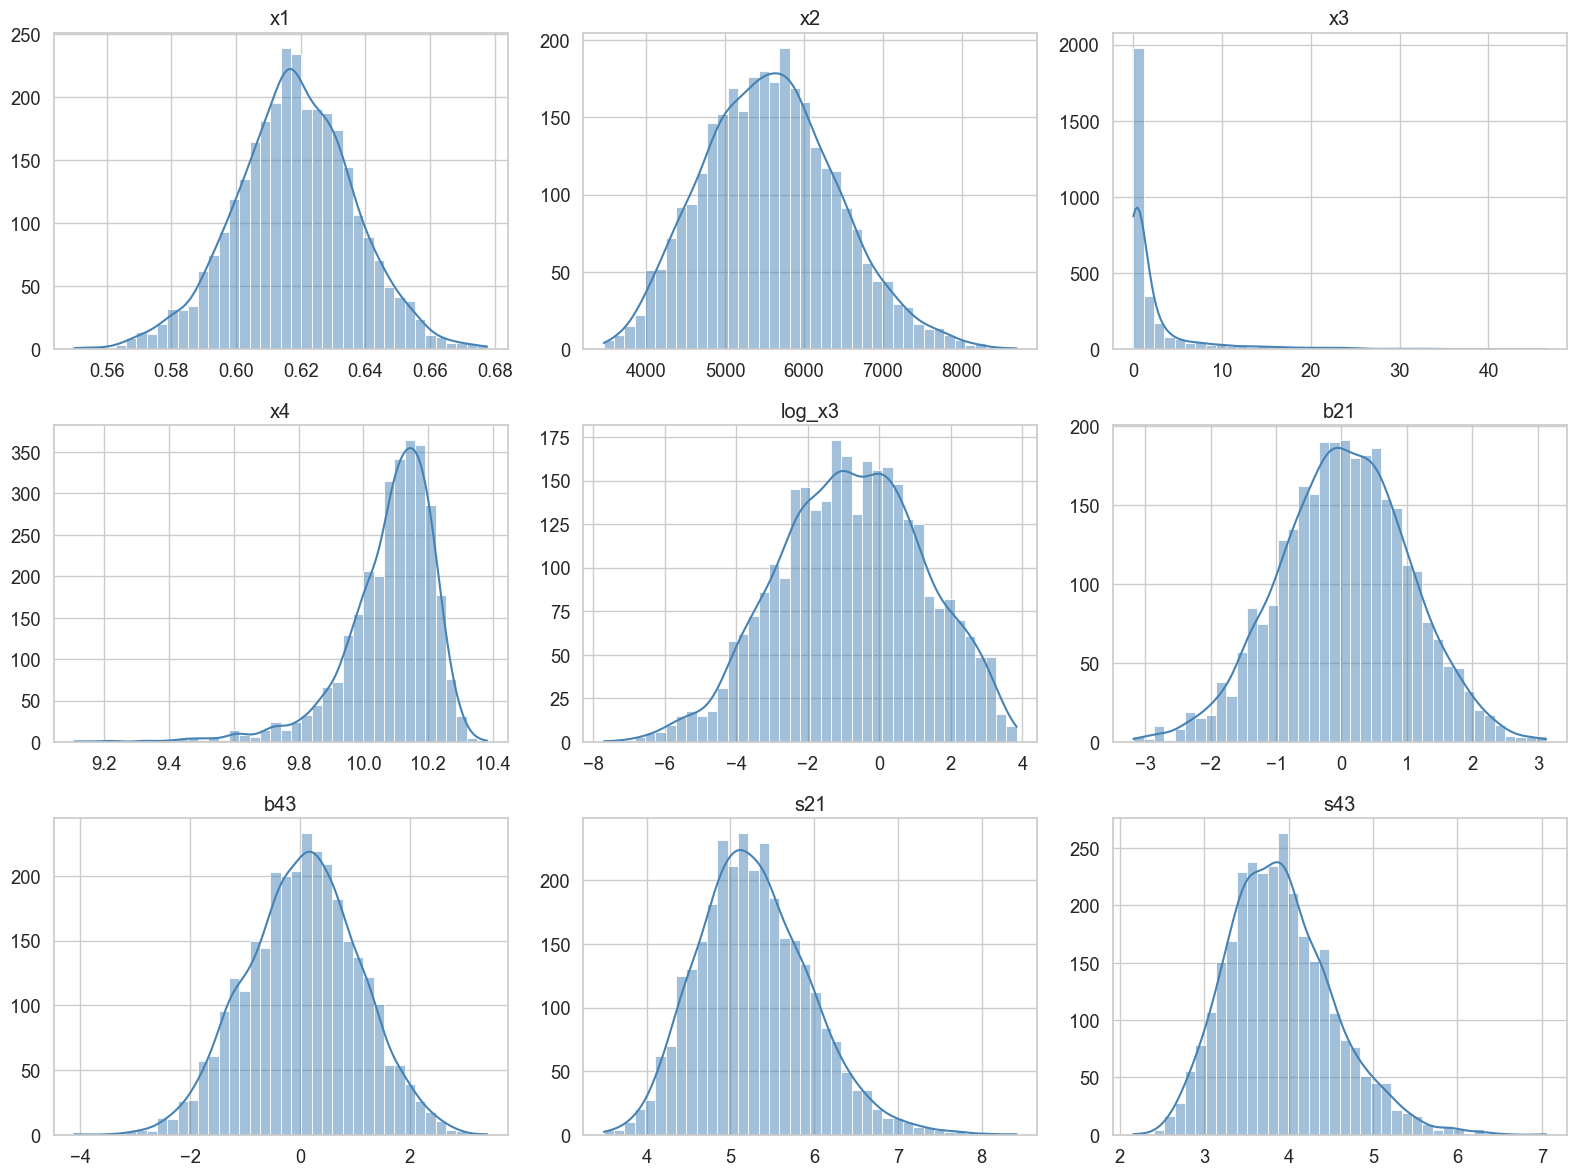

In [946]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


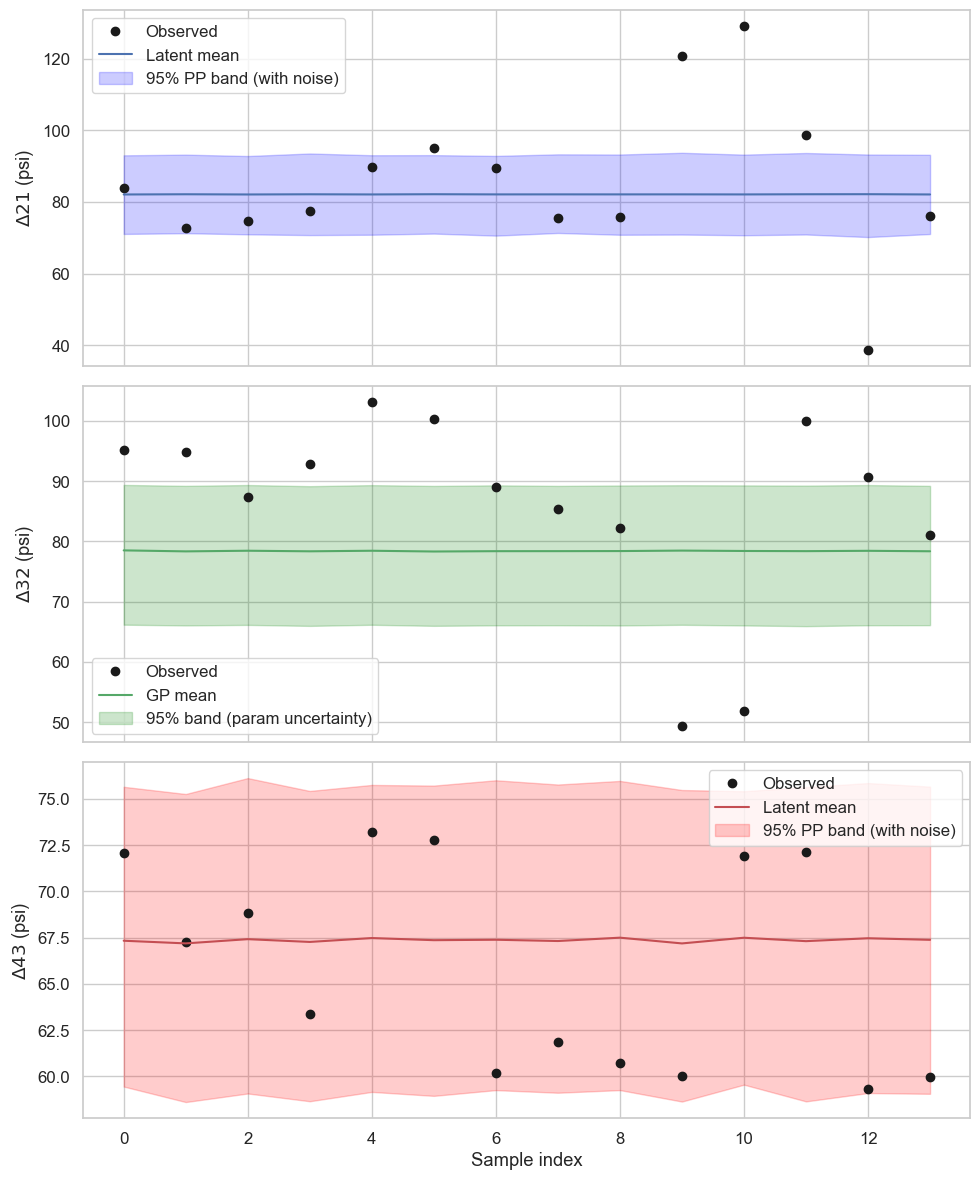

In [949]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values             # GP-scale x1 (as you stored it)
x2_s  = df["x2"].values * 10.0      # reverse earlier division, back to model scale if needed
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b21_s = df["b21"].values
b43_s = df["b43"].values
s21_s = df["s21"].values
s43_s = df["s43"].values

nsamp = len(df)

# ---------------------------------------------
# GP prediction function
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    # Adjust these calls if your gp_flow_maps expects scaled x1/x2
    f1 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# ---------------------------------------------
# Draw posterior predictive for each posterior sample
# ---------------------------------------------
m21_all, m32_all, m43_all = [], [], []
y21_all, y43_all = [], []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i] / 10.0, x3_s[i], x4_s[i], F
    )

    # latent means: Δ21 and Δ43 include bias; Δ32 is pure GP
    m21 = d21 + b21_s[i]
    m32 = d32
    m43 = d43 + b43_s[i]

    # noisy posterior predictive for Δ21 and Δ43
    y21 = m21 + np.random.normal(0, s21_s[i], size=len(m21))
    y43 = m43 + np.random.normal(0, s43_s[i], size=len(m43))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)
    y21_all.append(y21)
    y43_all.append(y43)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)
y21_all = np.vstack(y21_all)
y43_all = np.vstack(y43_all)

# ---------------------------------------------
# Summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

# Δ21: latent + noisy
m21_mean, m21_lo, m21_hi = summarise(m21_all)
y21_mean, y21_lo, y21_hi = summarise(y21_all)

# Δ32: GP-only (no noise calibration)
m32_mean, m32_lo, m32_hi = summarise(m32_all)

# Δ43: latent + noisy
m43_mean, m43_lo, m43_hi = summarise(m43_all)
y43_mean, y43_lo, y43_hi = summarise(y43_all)

# Observed
d21_obs = D[:, 0]
d32_obs = D[:, 1]
d43_obs = D[:, 2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21: full posterior predictive
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="Latent mean")
ax.fill_between(x, y21_lo, y21_hi, color="blue", alpha=0.2,
                label="95% PP band (with noise)")
ax.set_ylabel(r"$\Delta 21$ (psi)")
ax.legend()

# Δ32: GP-only (param uncertainty)
ax = axes[1]
ax.plot(x, d32_obs, "ko", label="Observed")
ax.plot(x, m32_mean, "g-", label="GP mean")
ax.fill_between(x, m32_lo, m32_hi, color="green", alpha=0.2,
                label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 32$ (psi)")
ax.legend()

# Δ43: full posterior predictive
ax = axes[2]
ax.plot(x, d43_obs, "ko", label="Observed")
ax.plot(x, m43_mean, "r-", label="Latent mean")
ax.fill_between(x, y43_lo, y43_hi, color="red", alpha=0.2,
                label="95% PP band (with noise)")
ax.set_ylabel(r"$\Delta 43$ (psi)")
ax.set_xlabel("Sample index")
ax.legend()

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


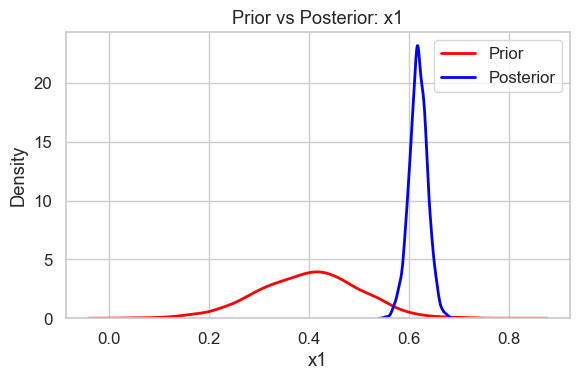

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


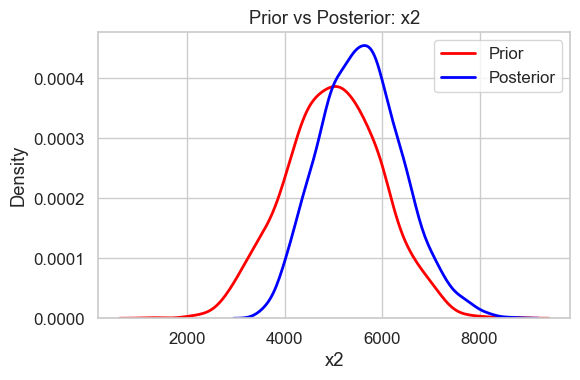

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


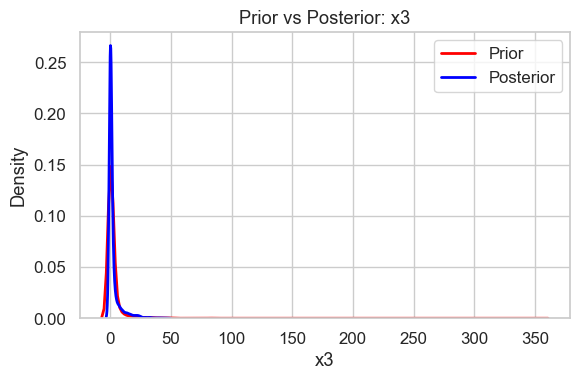

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


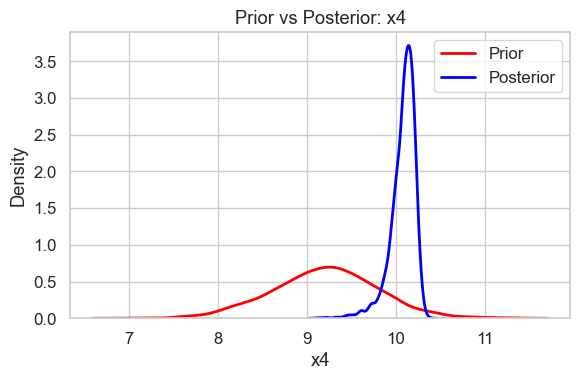

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


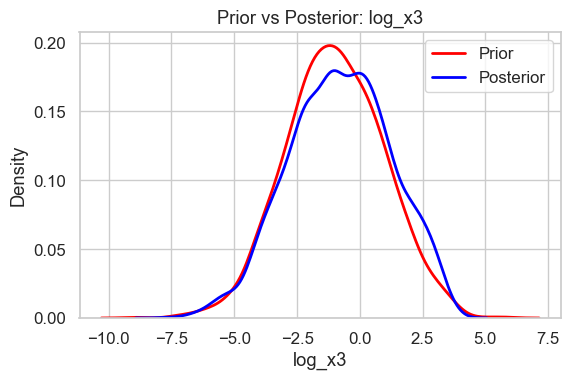

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


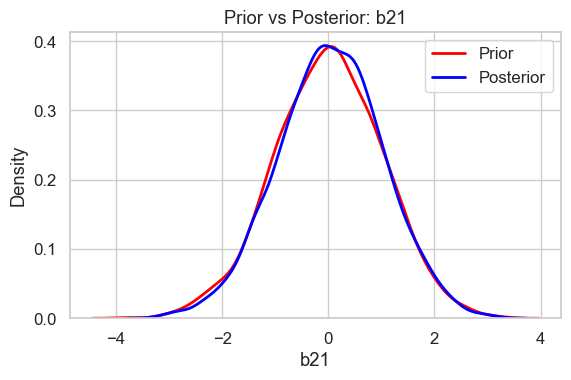

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


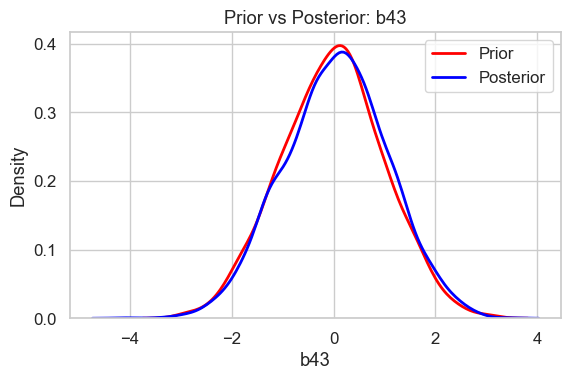

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


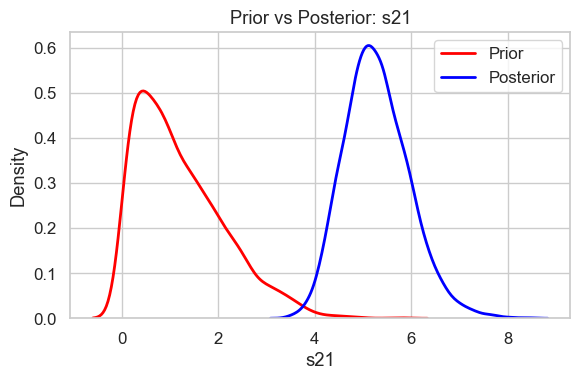

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


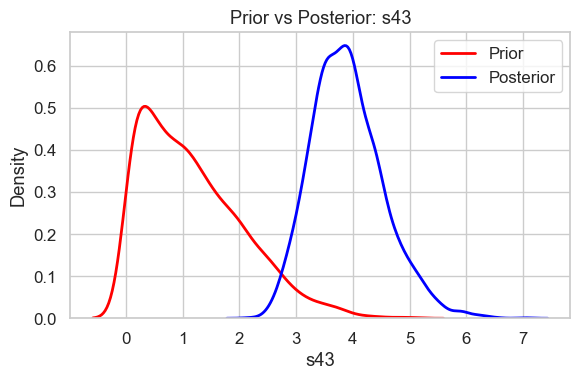

In [947]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3","b21", "b43","s21", "s43",]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [948]:
df.to_csv("posterior_samples_delta43and21.csv", index=False)
df_prior.to_csv("prior_samples_delta43and21.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv
